# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.validation import column_or_1d
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, HalvingGridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score, precision_recall_curve, make_scorer 
from sklearn.pipeline import Pipeline
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
import keras_tuner as kt
from sklearn.utils.class_weight import compute_sample_weight

# Import Data

In [3]:
x_train_AE = pd.read_csv('X_train_AE.csv')
y_train_AE = pd.read_csv('Y_train_AE.csv')

x_train_smote = pd.read_csv('X_train_SMOTE.csv')
y_train_smote = pd.read_csv('Y_train_SMOTE.csv')

x_train_smotetomek = pd.read_csv('X_train_smotetomek.csv')
y_train_smotetomek = pd.read_csv('Y_train_smotetomek.csv')

x_train_ros = pd.read_csv('X_train_ros.csv')
y_train_ros = pd.read_csv('Y_train_ros.csv')

x_train_original = pd.read_csv('X_train_original.csv')
y_train_original = pd.read_csv('Y_train_original.csv')

x_train_AE_RFE = pd.read_csv('X_train_AE_RFE.csv')
x_train_smote_RFE = pd.read_csv('X_train_SMOTE_RFE.csv')
x_train_smotetomek_RFE = pd.read_csv('X_train_smotetomek_RFE.csv')
x_train_ros_RFE = pd.read_csv('X_train_ros_RFE.csv')
x_train_original_RFE = pd.read_csv('X_train_original_RFE.csv')

x_train_AE_MI = pd.read_csv('X_train_AE_MI.csv')
x_train_smote_MI = pd.read_csv('X_train_SMOTE_MI.csv')
x_train_smotetomek_MI = pd.read_csv('X_train_smotetomek_MI.csv')
x_train_ros_MI = pd.read_csv('X_train_ros_MI.csv')
x_train_original_MI = pd.read_csv('X_train_original_MI.csv')

x_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('Y_test.csv')
x_test_RFE = pd.read_csv('X_test_RFE.csv')
x_test_MI = pd.read_csv('X_test_MI.csv')


In [4]:
print(f'Number of Train AE Samples: {x_train_AE.shape[0]}')
print(f'Number of Train Smotenc Samples: {x_train_smote.shape[0]}')
print(f'Number of Train SmoteTomek Samples: {x_train_smotetomek.shape[0]}')
print(f'Number of Train ros Samples: {x_train_ros.shape[0]}')
print(f'Number of Train original Samples: {x_train_original.shape[0]}')
print(f'Number of Test Samples: {x_test.shape[0]}')
print('\n########################################## \n')
print(f'Number of Train AE Features: {x_train_AE.shape[1]}')
print(f'Number of Train Smotenc Features: {x_train_smote.shape[1]}')
print(f'Number of Train SmoteTomek Features: {x_train_smotetomek.shape[1]}')
print(f'Number of Train ros Features: {x_train_ros.shape[1]}')
print(f'Number of Train original Features: {x_train_original.shape[1]}')
print(f'Number of Test Features: {x_test.shape[1]}')
print('\n==========================================\n========================================== \n')
print(f'Number of Train AE Samples -RFE Data-: {x_train_AE_RFE.shape[0]}')
print(f'Number of Train Smotenc Samples -RFE Data-: {x_train_smote_RFE.shape[0]}')
print(f'Number of Train SmoteTomek Samples -RFE Data-: {x_train_smotetomek_RFE.shape[0]}')
print(f'Number of Train ros Samples -RFE Data-: {x_train_ros_RFE.shape[0]}')
print(f'Number of Train original Samples -RFE Data-: {x_train_original_RFE.shape[0]}')
print(f'Number of Test Samples -RFE Data-: {x_test_RFE.shape[0]}')
print('\n########################################## \n')
print(f'Number of Train AE Features -RFE Data-: {x_train_AE_RFE.shape[1]}')
print(f'Number of Train Smotenc Features -RFE Data-: {x_train_smote_RFE.shape[1]}')
print(f'Number of Train SmoteTomek Features -RFE Data-: {x_train_smotetomek_RFE.shape[1]}')
print(f'Number of Train ros Features -RFE Data-: {x_train_ros_RFE.shape[1]}')
print(f'Number of Train original Features -RFE Data-: {x_train_original_RFE.shape[1]}')
print(f'Number of Test Features -RFE Data-: {x_test_RFE.shape[1]}')
print('\n******************************************\n****************************************** \n')
print('\n==========================================\n========================================== \n')
print(f'Number of Train AE Samples -MI Data-: {x_train_AE_MI.shape[0]}')
print(f'Number of Train Smotenc Samples -MI Data-: {x_train_smote_MI.shape[0]}')
print(f'Number of Train SmoteTomek Samples -MI Data-: {x_train_smotetomek_MI.shape[0]}')
print(f'Number of Train ros Samples -MI Data-: {x_train_ros_MI.shape[0]}')
print(f'Number of Train original Samples -MI Data-: {x_train_original_MI.shape[0]}')
print(f'Number of Test Samples -MI Data-: {x_test_MI.shape[0]}')
print('\n########################################## \n')
print(f'Number of Train AE Features -MI Data-: {x_train_AE_MI.shape[1]}')
print(f'Number of Train Smotenc Features -MI Data-: {x_train_smote_MI.shape[1]}')
print(f'Number of Train SmoteTomek Features -MI Data-: {x_train_smotetomek_MI.shape[1]}')
print(f'Number of Train ros Features -MI Data-: {x_train_ros_MI.shape[1]}')
print(f'Number of Train original Features -MI Data-: {x_train_original_MI.shape[1]}')
print(f'Number of Test Features -MI Data-: {x_test_MI.shape[1]}')
print('\n******************************************\n****************************************** \n')
print(f'Number of Train AE Targets: {y_train_AE.shape[0]}')
print(f'Number of Train Smotenc Targets: {y_train_smote.shape[0]}')
print(f'Number of Train SmoteTomek Targets: {y_train_smotetomek.shape[0]}')
print(f'Number of Train ros Targets: {y_train_ros.shape[0]}')
print(f'Number of Train original Targets: {y_train_original.shape[0]}')
print(f'Number of Test Targets: {y_test.shape[0]}')


Number of Train AE Samples: 40371
Number of Train Smotenc Samples: 37043
Number of Train SmoteTomek Samples: 35944
Number of Train ros Samples: 33338
Number of Train original Samples: 32533
Number of Test Samples: 16275

########################################## 

Number of Train AE Features: 33
Number of Train Smotenc Features: 33
Number of Train SmoteTomek Features: 33
Number of Train ros Features: 33
Number of Train original Features: 33
Number of Test Features: 33


Number of Train AE Samples -RFE Data-: 40371
Number of Train Smotenc Samples -RFE Data-: 37043
Number of Train SmoteTomek Samples -RFE Data-: 35944
Number of Train ros Samples -RFE Data-: 33338
Number of Train original Samples -RFE Data-: 32533
Number of Test Samples -RFE Data-: 16275

########################################## 

Number of Train AE Features -RFE Data-: 4
Number of Train Smotenc Features -RFE Data-: 4
Number of Train SmoteTomek Features -RFE Data-: 4
Number of Train ros Features -RFE Data-: 4
Number of 

# Normalization

In [5]:
x_train_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37043 entries, 0 to 37042
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           37043 non-null  float64
 1   education_num                 37043 non-null  int64  
 2   sex                           37043 non-null  int64  
 3   hours_per_week                37043 non-null  float64
 4   log_capital_gain              37043 non-null  float64
 5   log_capital_loss              37043 non-null  float64
 6   workclass_Federal-gov         37043 non-null  int64  
 7   workclass_Local-gov           37043 non-null  int64  
 8   workclass_Other               37043 non-null  int64  
 9   workclass_Private             37043 non-null  int64  
 10  workclass_Self-emp-inc        37043 non-null  int64  
 11  workclass_Self-emp-not-inc    37043 non-null  int64  
 12  workclass_State-gov           37043 non-null  int64  
 13  m

In [6]:
conti_features = x_train_smote.select_dtypes(include='float').columns.to_list() + ['education_num']
conti_features_RFE = x_train_smote_RFE.select_dtypes(include='float').columns.to_list() + ['education_num']
conti_features_MI = x_train_smote_MI.select_dtypes(include='float').columns.to_list() + ['education_num']

In [7]:
print(f'Continues Features of Original Data: {conti_features}')
print('Continues Features of RFE Data: {}'.format(conti_features_RFE))
print(f'Continues Features of MI Data: {conti_features_MI}')

Continues Features of Original Data: ['age', 'hours_per_week', 'log_capital_gain', 'log_capital_loss', 'education_num']
Continues Features of RFE Data: ['age', 'log_capital_gain', 'education_num']
Continues Features of MI Data: ['age', 'hours_per_week', 'log_capital_gain', 'education_num']


In [8]:
minmaxscale_original = MinMaxScaler()
minmaxscale_RFECV = MinMaxScaler()

In [9]:
x_train_AE_norm = x_train_AE.copy()
x_train_smote_norm = x_train_smote.copy()
x_train_smotetomek_norm = x_train_smotetomek.copy()
x_train_original_norm = x_train_original.copy()
x_test_norm = x_test.copy()

x_train_AE_RFE_norm = x_train_AE_RFE.copy()
x_train_smote_RFE_norm = x_train_smote_RFE.copy()
x_train_smotetomek_RFE_norm = x_train_smotetomek_RFE.copy()
x_train_original_RFE_norm = x_train_original_RFE.copy()
x_test_RFE_norm = x_test_RFE.copy()

x_train_AE_MI_norm = x_train_AE_MI.copy()
x_train_smote_MI_norm = x_train_smote_MI.copy()
x_train_smotetomek_MI_norm = x_train_smotetomek_MI.copy()
x_train_original_MI_norm = x_train_original_MI.copy()
x_test_MI_norm = x_test_MI.copy()

x_train_AE_norm[conti_features] = minmaxscale_original.fit_transform(x_train_AE_norm[conti_features])
x_train_smote_norm[conti_features] = minmaxscale_original.fit_transform(x_train_smote_norm[conti_features])
x_train_smotetomek_norm[conti_features] = minmaxscale_original.fit_transform(x_train_smotetomek_norm[conti_features])
x_train_original_norm[conti_features] = minmaxscale_original.fit_transform(x_train_original_norm[conti_features])
x_test_norm[conti_features] = minmaxscale_original.transform(x_test[conti_features])

x_train_AE_RFE_norm[conti_features_RFE] = minmaxscale_original.fit_transform(x_train_AE_RFE_norm[conti_features_RFE])
x_train_smote_RFE_norm[conti_features_RFE] = minmaxscale_original.fit_transform(x_train_smote_RFE_norm[conti_features_RFE])
x_train_smotetomek_RFE_norm[conti_features_RFE] = minmaxscale_original.fit_transform(x_train_smotetomek_RFE_norm[conti_features_RFE])
x_train_original_RFE_norm[conti_features_RFE] = minmaxscale_original.fit_transform(x_train_original_RFE_norm[conti_features_RFE])
x_test_RFE_norm[conti_features_RFE] = minmaxscale_original.transform(x_test_RFE[conti_features_RFE])

x_train_AE_MI_norm[conti_features_MI] = minmaxscale_original.fit_transform(x_train_AE_MI_norm[conti_features_MI])
x_train_smote_MI_norm[conti_features_MI] = minmaxscale_original.fit_transform(x_train_smote_MI_norm[conti_features_MI])
x_train_smotetomek_MI_norm[conti_features_MI] = minmaxscale_original.fit_transform(x_train_smotetomek_MI_norm[conti_features_MI])
x_train_original_MI_norm[conti_features_MI] = minmaxscale_original.fit_transform(x_train_original_MI_norm[conti_features_MI])
x_test_MI_norm[conti_features_MI] = minmaxscale_original.transform(x_test_MI[conti_features_MI])

In [10]:
x_train_smote.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,...,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000
mean,39.266258,3.557730,0.692439,41.010825,0.891774,0.412359,0.030451,0.065168,0.053127,0.694679,...,0.047242,0.502605,0.497395,0.030937,0.104095,0.864968,0.028750,0.050941,0.017250,0.903059
std,13.377566,2.088812,0.461490,12.168251,2.717605,1.737686,0.171827,0.246825,0.224291,0.460549,...,0.212160,0.500000,0.500000,0.173149,0.305388,0.341763,0.167106,0.219880,0.130204,0.295882
min,17.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,2.000000,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,38.000000,3.000000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,48.000000,6.000000,1.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,9.000000,1.000000,99.000000,12.000000,8.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
x_test.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,...,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000
mean,38.770691,3.385192,0.666974,40.392688,0.716689,0.352404,0.029002,0.064086,0.059785,0.688541,...,0.046575,0.447558,0.552442,0.029493,0.113978,0.856528,0.026544,0.054009,0.018925,0.900522
std,13.849887,2.017044,0.471310,12.477127,2.427403,1.589703,0.167816,0.244914,0.237095,0.463104,...,0.210732,0.497257,0.497257,0.169189,0.317795,0.350564,0.160751,0.226043,0.136263,0.299312
min,17.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,2.000000,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,37.000000,3.000000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,48.000000,5.000000,1.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,9.000000,1.000000,99.000000,11.510000,8.240000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
x_train_smote_norm.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,...,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000
mean,0.305017,0.319716,0.692439,0.408274,0.074315,0.051545,0.030451,0.065168,0.053127,0.694679,...,0.047242,0.502605,0.497395,0.030937,0.104095,0.864968,0.028750,0.050941,0.017250,0.903059
std,0.183254,0.261102,0.461490,0.124166,0.226467,0.217211,0.171827,0.246825,0.224291,0.460549,...,0.212160,0.500000,0.500000,0.173149,0.305388,0.341763,0.167106,0.219880,0.130204,0.295882
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.164384,0.125000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,0.287671,0.250000,1.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,0.424658,0.625000,1.000000,0.448980,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
x_test_norm.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,...,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000
mean,0.298229,0.298149,0.666974,0.401966,0.062267,0.042053,0.029002,0.064086,0.059785,0.688541,...,0.046575,0.447558,0.552442,0.029493,0.113978,0.856528,0.026544,0.054009,0.018925,0.900522
std,0.189724,0.252131,0.471310,0.127318,0.210895,0.189702,0.167816,0.244914,0.237095,0.463104,...,0.210732,0.497257,0.497257,0.169189,0.317795,0.350564,0.160751,0.226043,0.136263,0.299312
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.125000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,0.273973,0.250000,1.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,0.424658,0.500000,1.000000,0.448980,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.983294,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
x_train_smote_RFE.describe()

,age,education_num,log_capital_gain,relationship_Family
count,37043.000000,37043.000000,37043.000000,37043.000000
mean,39.266258,3.557730,0.891774,0.502605
std,13.377566,2.088812,2.717605,0.500000
min,17.000000,1.000000,0.000000,0.000000
25%,29.000000,2.000000,0.000000,0.000000
50%,38.000000,3.000000,0.000000,1.000000
75%,48.000000,6.000000,0.000000,1.000000
max,90.000000,9.000000,12.000000,1.000000


In [15]:
x_test_RFE.describe()

,age,education_num,log_capital_gain,relationship_Family
count,16275.000000,16275.000000,16275.000000,16275.000000
mean,38.770691,3.385192,0.716689,0.447558
std,13.849887,2.017044,2.427403,0.497257
min,17.000000,1.000000,0.000000,0.000000
25%,28.000000,2.000000,0.000000,0.000000
50%,37.000000,3.000000,0.000000,0.000000
75%,48.000000,5.000000,0.000000,1.000000
max,90.000000,9.000000,11.510000,1.000000


In [16]:
x_train_smote_RFE_norm.describe()

,age,education_num,log_capital_gain,relationship_Family
count,37043.000000,37043.000000,37043.000000,37043.000000
mean,0.305017,0.319716,0.074315,0.502605
std,0.183254,0.261102,0.226467,0.500000
min,0.000000,0.000000,0.000000,0.000000
25%,0.164384,0.125000,0.000000,0.000000
50%,0.287671,0.250000,0.000000,1.000000
75%,0.424658,0.625000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [17]:
x_test_RFE_norm.describe()

,age,education_num,log_capital_gain,relationship_Family
count,16275.000000,16275.000000,16275.000000,16275.000000
mean,0.298229,0.298149,0.062267,0.447558
std,0.189724,0.252131,0.210895,0.497257
min,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.125000,0.000000,0.000000
50%,0.273973,0.250000,0.000000,0.000000
75%,0.424658,0.500000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [18]:
x_train_smote_MI_norm.describe()

,age,education_num,hours_per_week,log_capital_gain,marital_status_Married,marital_status_Other,relationship_Family,relationship_Other
count,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000,37043.000000
mean,0.305017,0.319716,0.408274,0.074315,0.509030,0.490970,0.502605,0.497395
std,0.183254,0.261102,0.124166,0.226467,0.499925,0.499925,0.500000,0.500000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.164384,0.125000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.287671,0.250000,0.397959,0.000000,1.000000,0.000000,1.000000,0.000000
75%,0.424658,0.625000,0.448980,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
x_test_MI_norm.describe()

,age,education_num,hours_per_week,log_capital_gain,marital_status_Married,marital_status_Other,relationship_Family,relationship_Other
count,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000
mean,0.298229,0.298149,0.401966,0.062267,0.455607,0.544393,0.447558,0.552442
std,0.189724,0.252131,0.127318,0.210895,0.498041,0.498041,0.497257,0.497257
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.125000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.273973,0.250000,0.397959,0.000000,0.000000,1.000000,0.000000,1.000000
75%,0.424658,0.500000,0.448980,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Model Training

In [20]:
StKFold = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

### Find Best Data

In [21]:
Data_Table = {'name':['Original', 'AE', 'SMOTE', 'SMOTETomek','ROS'],
               'X': [[x_train_original], [x_train_AE], [x_train_smote], [x_train_smotetomek], [x_train_ros]],
                 'Y': [[y_train_original], [y_train_AE], [y_train_smote], [y_train_smotetomek], [y_train_ros]]}

In [21]:
GBC_model = GradientBoostingClassifier(random_state=42)

GBC_N_Estimators = np.arange(start=50, stop=401, step=50)
GBC_learning_rate = [0.1, 0.2, 0.3]
min_split_GB = [2,3]
max_depth_GB = [3,5,8]
min_samples_leaf_GB = [1,2]

param_grid_GB = {
    'n_estimators': GBC_N_Estimators,
    'learning_rate' : GBC_learning_rate,
    # 'min_samples_split' : min_split_GB,
    'max_depth' : max_depth_GB,
    # 'min_samples_leaf' : min_samples_leaf_GB,
}

DataType = list(range(len(Data_Table['name']))) * 4

Sample_weight_States = ([0]*len(Data_Table['name']) + [0]*len(Data_Table['name']) + 
                        [1]*len(Data_Table['name']) + [1]*len(Data_Table['name']))

Tune_Threshold_States = ([0]*len(Data_Table['name']) + [1]*len(Data_Table['name']) + 
                         [0]*len(Data_Table['name']) + [1]*len(Data_Table['name']))

Information_States = []

for d, s, t in zip(DataType, Sample_weight_States, Tune_Threshold_States ):

    
    Sample_Weights = compute_sample_weight(class_weight='balanced', y=Data_Table['Y'][d][0]) if s == 1 else None
       
    GBC_model_optimized_GS_Original = HalvingGridSearchCV(estimator=GBC_model, param_grid=param_grid_GB, scoring='f1_macro', 
                                                          cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, 
                                                          verbose=3, n_jobs=5)
    
    GBC_model_optimized_GS_Original.fit(Data_Table['X'][d][0], column_or_1d(Data_Table['Y'][d][0]), sample_weight=Sample_Weights)

    if t == 1:

        y_prob = GBC_model_optimized_GS_Original.predict_proba(Data_Table['X'][d][0])[:,1]
        precisions, recalls, thresholds = precision_recall_curve(column_or_1d(Data_Table['Y'][d][0]), y_prob, pos_label=1)

        f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]

        y_prob_test = GBC_model_optimized_GS_Original.predict_proba(x_test)[:,1]
        y_pred = (y_prob_test > best_threshold).astype(int)

    else:

        y_pred = GBC_model_optimized_GS_Original.best_estimator_.predict(x_test)
        

    pre_score = np.round(precision_score(column_or_1d(y_test),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    rec_score = np.round(recall_score(column_or_1d(y_test),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    acc_score = np.round(accuracy_score(column_or_1d(y_test),column_or_1d(y_pred)), decimals=2)
    f1 = np.round(f1_score(column_or_1d(y_test),column_or_1d(y_pred), average='macro'), decimals=2)

    Information_States.append({'Model Name': 'GBC', 'DataSet Type': '{}'.format(Data_Table['name'][d]),
                               'Tune Threshold': 'On' if t==1 else 'Off', 'Sample Weight': 'On' if s==1 else 'Off',
                                'Low Income Precision': pre_score[0], 'High Income Precision': pre_score[1],
                                'Low Income Recall': rec_score[0], 'High Income Recall': rec_score[1], 
                                'Accuracy': acc_score, 'Mean F1 Score': f1})

DF_Information_States = pd.DataFrame(Information_States)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1204
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 72
n_resources: 1204
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 1
n_candidates: 24
n_resources: 3612
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 2
n_candidates: 8
n_resources: 10836
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 3
n_candidates: 3
n_resources: 32508
Fitting 5 folds for each of 3 candidates, totalling 15 fits
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1495
max_resources_: 40371
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 72
n_resources: 1495
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 1
n_candidates: 24
n_resources: 4485
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------

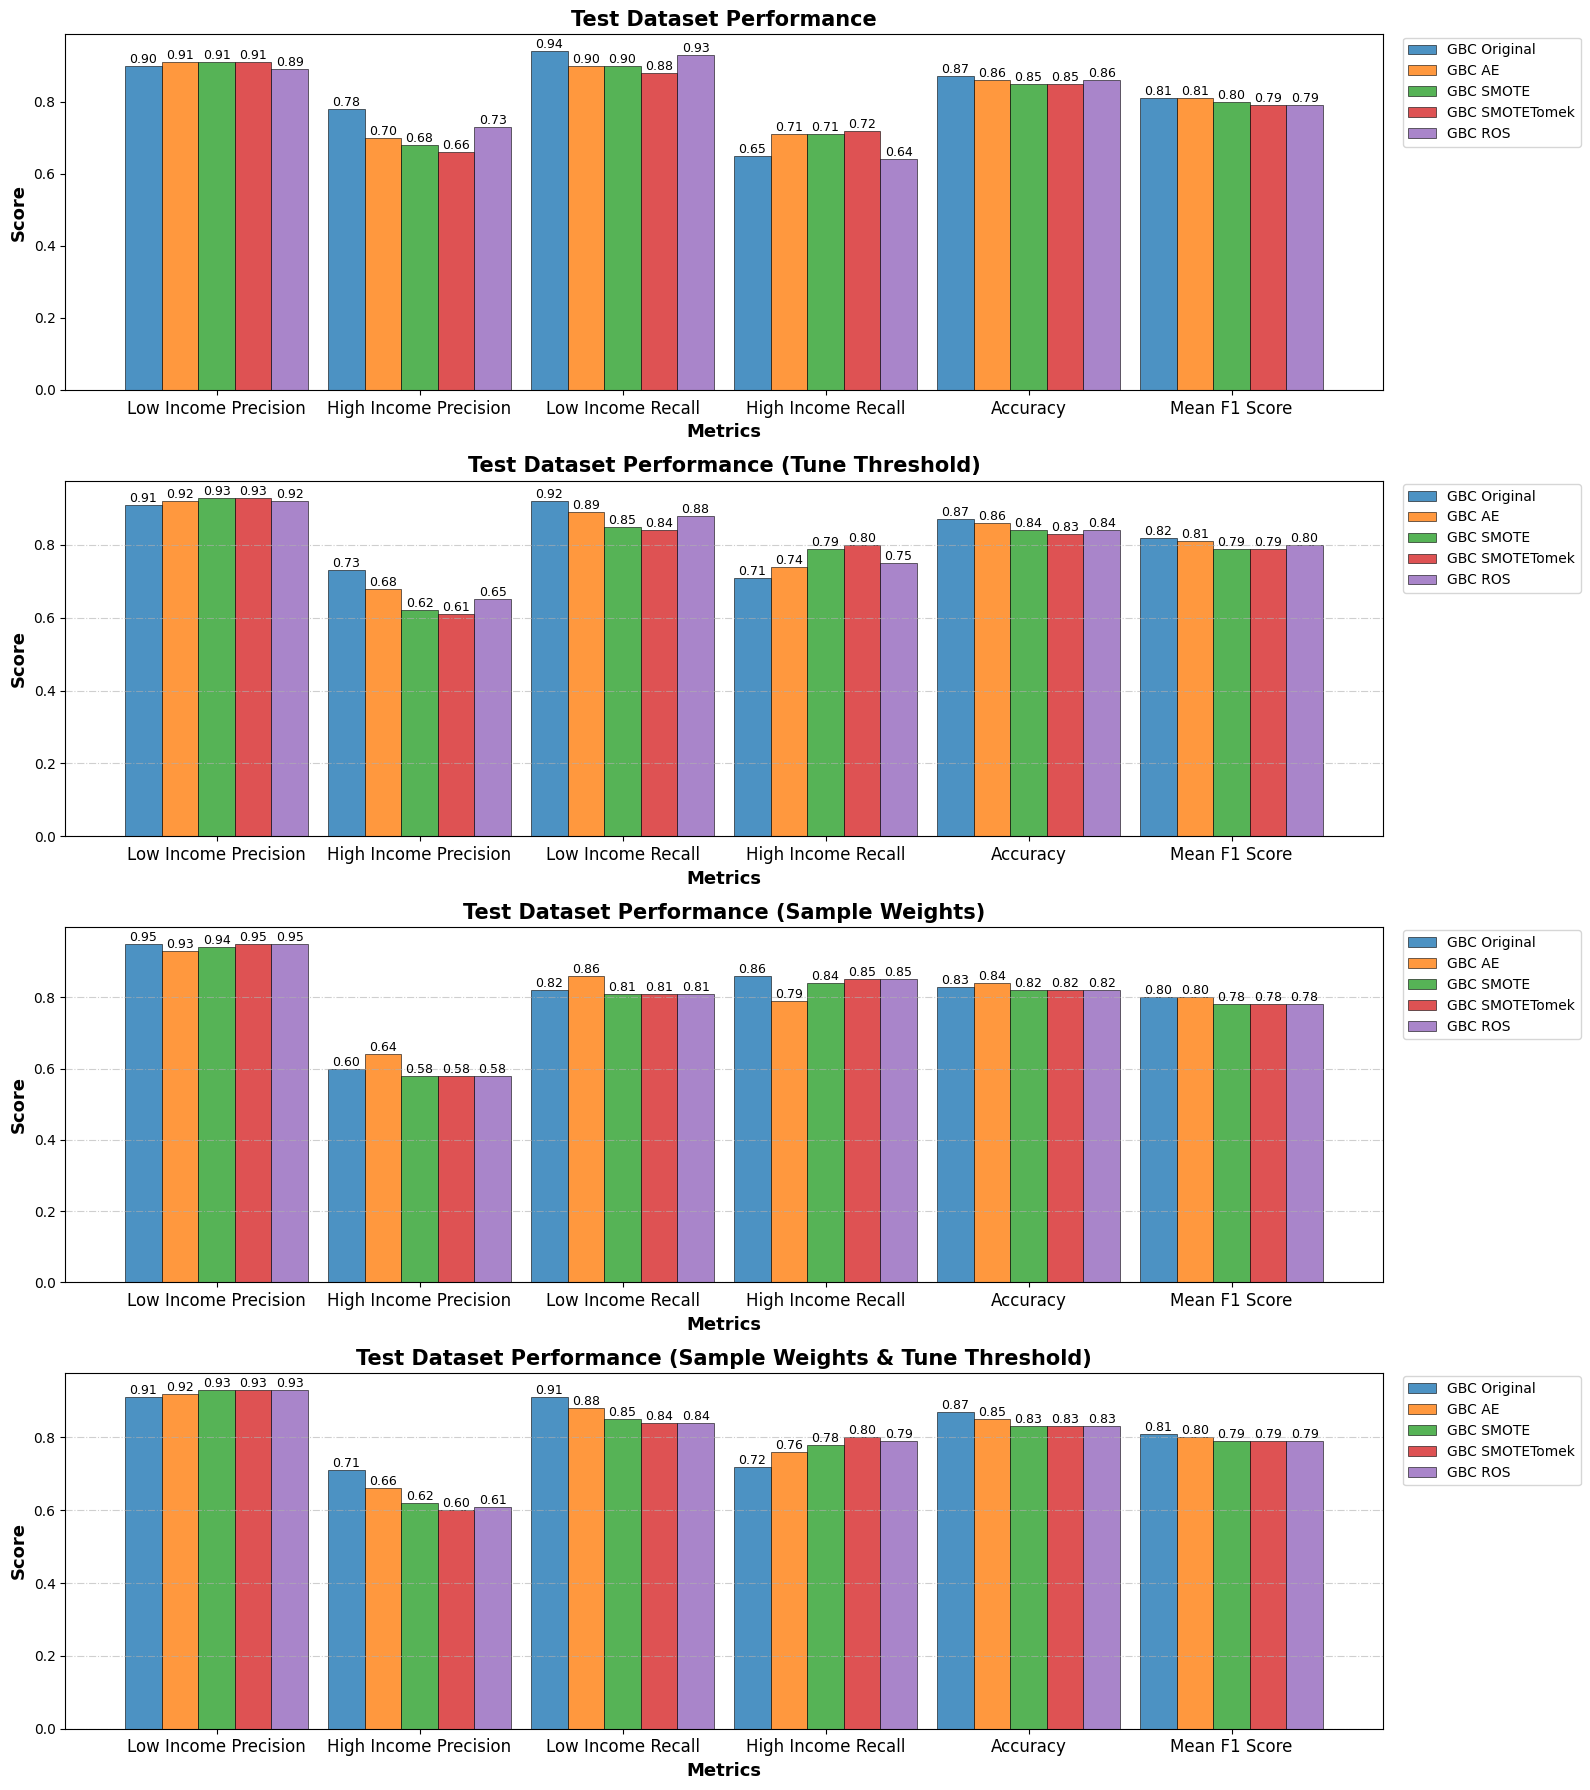

In [22]:

fig, axes = plt.subplots(4,1,figsize=(16, 18))

metrics = [col for col in DF_Information_States.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
           and col != 'Sample Weight']

x = np.arange(len(metrics))       # positions for metrics on xticks
width = 0.9 / (DF_Information_States.shape[0] / 4)             

j_1 = 0
j_2 = 0
j_3 = 0
j_4 = 0

for (idx, row) in DF_Information_States.iterrows():

    model_name = row['Model Name']
    Data_Type = row['DataSet Type']

    if row['Tune Threshold'] == 'Off' and row['Sample Weight'] == 'Off':

        values = [row[metric] for metric in metrics]
        
        # Calculate bar positions
        bar_positions = x + (j_1 - len(DF_Information_States)/8 + 0.5) * width
        
        bars = axes[0].bar(bar_positions, values, width,
                    label=f'{model_name} {Data_Type}', 
                    edgecolor='black', 
                    linewidth=0.5,
                    alpha=0.8)
        
        # Add value labels on top of bars
        for bar, val in zip(bars, values):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, rotation=0)

        j_1 += 1

    if row['Tune Threshold'] == 'On' and row['Sample Weight'] == 'Off':    

        values = [row[metric] for metric in metrics]
        
        # Calculate bar positions
        bar_positions = x + (j_2 - len(DF_Information_States)/8 + 0.5) * width
        
        bars = axes[1].bar(bar_positions, values, width,
                    label=f'{model_name} {Data_Type}', 
                    edgecolor='black', 
                    linewidth=0.5,
                    alpha=0.8)
        
        # Add value labels on top of bars
        for bar, val in zip(bars, values):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, rotation=0)
        j_2 += 1  

    if row['Tune Threshold'] == 'Off' and row['Sample Weight'] == 'On':

        values = [row[metric] for metric in metrics]
        
        # Calculate bar positions
        bar_positions = x + (j_3 - len(DF_Information_States)/8 + 0.5) * width
        
        bars = axes[2].bar(bar_positions, values, width,
                    label=f'{model_name} {Data_Type}', 
                    edgecolor='black', 
                    linewidth=0.5,
                    alpha=0.8)
        
        # Add value labels on top of bars
        for bar, val in zip(bars, values):
            axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, rotation=0)
        j_3 += 1  

    if row['Tune Threshold'] == 'On' and row['Sample Weight'] == 'On':

        values = [row[metric] for metric in metrics]
        
        # Calculate bar positions
        bar_positions = x + (j_4 - len(DF_Information_States)/8 + 0.5) * width
        
        bars = axes[3].bar(bar_positions, values, width,
                    label=f'{model_name} {Data_Type}', 
                    edgecolor='black', 
                    linewidth=0.5,
                    alpha=0.8)
        
        # Add value labels on top of bars
        for bar, val in zip(bars, values):
            axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, rotation=0)
        j_4 += 1

axes[0].set_title('Test Dataset Performance', fontsize=15, weight='bold')
axes[0].set_xlabel('Metrics', fontsize=13, weight='bold')
axes[0].set_ylabel('Score', fontsize=13, weight='bold')
axes[0].set_xticks(x, metrics, fontsize=12)
axes[0].legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)  
axes[0].legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       # write Upper Left to locate legend outside the plot based bbox_to_anchor values
           
axes[1].set_title('Test Dataset Performance (Tune Threshold)', fontsize=15, weight='bold')
axes[1].set_xlabel('Metrics', fontsize=13, weight='bold')
axes[1].set_ylabel('Score', fontsize=13, weight='bold')
axes[1].set_xticks(x, metrics, fontsize=12)
axes[1].grid(True, axis='y', linestyle='-.', alpha=0.6)
axes[1].legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)    

axes[2].set_title('Test Dataset Performance (Sample Weights)', fontsize=15, weight='bold')
axes[2].set_xlabel('Metrics', fontsize=13, weight='bold')
axes[2].set_ylabel('Score', fontsize=13, weight='bold')
axes[2].set_xticks(x, metrics, fontsize=12)
axes[2].grid(True, axis='y', linestyle='-.', alpha=0.6)
axes[2].legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)

axes[3].set_title('Test Dataset Performance (Sample Weights & Tune Threshold)', fontsize=15, weight='bold')
axes[3].set_xlabel('Metrics', fontsize=13, weight='bold')
axes[3].set_ylabel('Score', fontsize=13, weight='bold')
axes[3].set_xticks(x, metrics, fontsize=12)
axes[3].grid(True, axis='y', linestyle='-.', alpha=0.6)
axes[3].legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       

plt.tight_layout()
plt.show()

In [21]:
def best_threshold(X,Y,best_estimator):
    
    y_prob = best_estimator.predict_proba(X)[:,1]
    precisions, recalls, thresholds = precision_recall_curve(column_or_1d(Y), y_prob)

    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print(f'Best Threshold : {best_threshold:.2f}')
    print(f'Best F1 Score for high income : {f1_scores[best_idx]:.2f}')

    plt.figure(figsize=(9,7))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', linestyle="--")
    plt.plot(thresholds, recalls[:-1], label='Recall', color='green', linestyle="-")
    plt.axvline(best_threshold, color='red', label=f'Best Threshold ({best_threshold:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision & Recall vs. Decision Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_threshold, y_prob


In [22]:
def display_CM(X,Y,best_threshold,best_estimator,TTS):

    if TTS == 1:
        y_prob = best_estimator.predict_proba(X)[:,1]
        y_pred = (y_prob > best_threshold).astype(int)
    else:
        y_pred = best_estimator.predict(X)

    CM_Test = confusion_matrix(column_or_1d(Y),column_or_1d(y_pred))
    pre_score = np.round(precision_score(column_or_1d(Y),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    rec_score = np.round(recall_score(column_or_1d(Y),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    acc_score = np.round(accuracy_score(column_or_1d(Y),column_or_1d(y_pred)), decimals=2)
    f1 = np.round(f1_score(column_or_1d(Y),column_or_1d(y_pred), average='macro'), decimals=2)
    CM = np.concatenate((np.vstack((CM_Test,pre_score)),np.hstack((rec_score,acc_score)).reshape(3,1)), axis=1)
    df_CM = pd.DataFrame(CM, index=['<=50k', '>50k', 'Precision'], columns=['<=50k', '>50k', 'Recall'])

    plt.figure(figsize=(5,5))
    sns.heatmap(df_CM, annot=True, cbar=False, cmap=plt.cm.Blues, fmt='.5g')
    plt.xlabel('Predicted Label', fontsize=11, weight='bold')
    plt.ylabel('True Label', fontsize=11, weight='bold')
    plt.title('Confusion Matrix', fontsize=13, weight='bold')
    plt.show()

    return f1, pre_score, rec_score, acc_score

In [23]:
def threshold_optimized_f1_macro(y_true, y_proba):
  
    # y_proba might be 1D or 2D
    if len(y_proba.shape) > 1:
        y_proba = y_proba[:, 1]
        
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred = (y_proba > best_threshold).astype(int)
    
    return f1_score(y_true, y_pred, average='macro')

optimized_f1_scorer = make_scorer(score_func = threshold_optimized_f1_macro, response_method = 'predict_proba')

### KNN

In [49]:
knn_model = KNeighborsClassifier()

knn_pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('knn',knn_model)
])

N_Neighbors = [5,7,9,11,13,15,17]
Knn_weights = ['uniform', 'distance'] 

param_grid_KNN = {
    'knn__n_neighbors': N_Neighbors,
    'knn__weights' : Knn_weights,
}

#### Original Data - Tune Threshold

In [50]:
knn_model_optimized_GS_Original_TT = HalvingGridSearchCV(estimator=knn_pipe, param_grid=param_grid_KNN, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
knn_model_optimized_GS_Original_TT.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 3614
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 14
n_resources: 3614
Fitting 5 folds for each of 14 candidates, totalling 70 fits
----------
iter: 1
n_candidates: 5
n_resources: 10842
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 2
n_candidates: 2
n_resources: 32526
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [5, 7, ...], 'knn__weights': ['uniform', 'distance']}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [51]:
best_score_KNN_Original_TT = knn_model_optimized_GS_Original_TT.best_score_
print(f'KNN Best Score: {best_score_KNN_Original_TT:.2f}')
best_params_KNN_Original_TT = knn_model_optimized_GS_Original_TT.best_params_
print(f'KNN Best Score: {best_params_KNN_Original_TT}')

Best_KNN_Original_TT_Estimator = knn_model_optimized_GS_Original_TT.best_estimator_

KNN Best Score: 0.77
KNN Best Score: {'knn__n_neighbors': 15, 'knn__weights': 'uniform'}


Best Threshold : 0.40
Best F1 Score for high income : 0.70


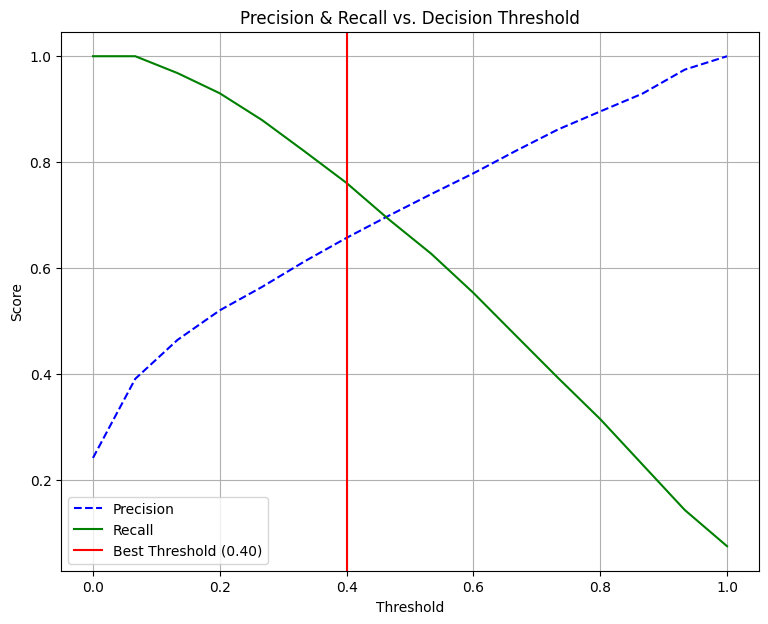

In [52]:
best_threshold_KNN_Original_TT, y_proba_KNN_Original_TT = best_threshold(x_train_original, y_train_original, 
                                                                         Best_KNN_Original_TT_Estimator)

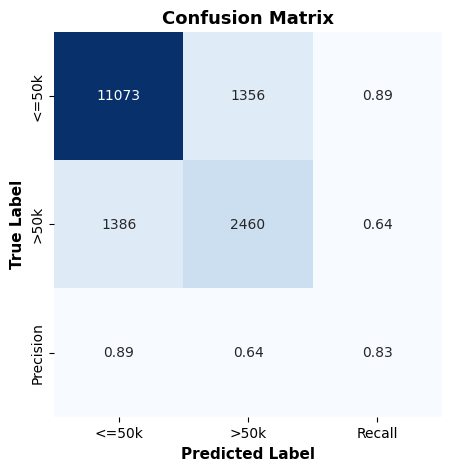

In [53]:
f1_KNN_Original_TT, precision_KNN_Original_TT, recall_KNN_Original_TT, accuracy_KNN_Original_TT = display_CM(x_test, y_test, 
                                                                                                 best_threshold_KNN_Original_TT, 
                                                                                                 Best_KNN_Original_TT_Estimator,1)

In [54]:
Score_Information = [{'Model Name': 'KNN', 'DataSet Type': 'Original' ,'Low Income Precision': precision_KNN_Original_TT[0], 
                      'High Income Precision': precision_KNN_Original_TT[1],'Low Income Recall': recall_KNN_Original_TT[0], 
                      'High Income Recall': recall_KNN_Original_TT[1], 'Accuracy': accuracy_KNN_Original_TT, 
                      'Mean F1 Score': f1_KNN_Original_TT, 'Tune Threshold': 'On', 'Sample Weight': 'Off'}]


#### Original Data - None Tune Threshold

In [55]:
best_score_KNN_Original_NTT = knn_model_optimized_GS_Original_TT.best_score_
print(f'KNN Best Score: {best_score_KNN_Original_NTT:.2f}')
best_params_KNN_Original_NTT = knn_model_optimized_GS_Original_TT.best_params_
print(f'KNN Best Score: {best_params_KNN_Original_NTT}')

Best_KNN_Original_NTT_Estimator = knn_model_optimized_GS_Original_TT.best_estimator_

KNN Best Score: 0.77
KNN Best Score: {'knn__n_neighbors': 15, 'knn__weights': 'uniform'}


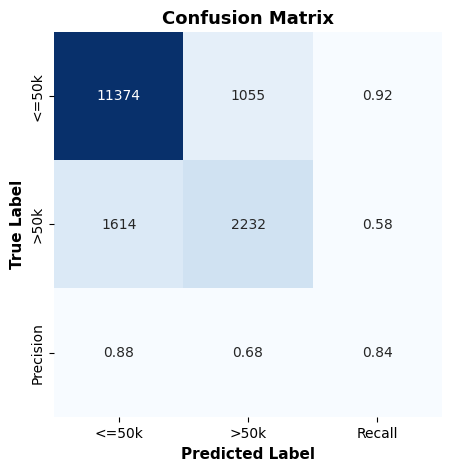

In [56]:
f1_KNN_Original_NTT, precision_KNN_Original_NTT, recall_KNN_Original_NTT, accuracy_KNN_Original_NTT = display_CM(x_test, y_test, 
                                                                                                0.5, Best_KNN_Original_NTT_Estimator,0)

In [57]:
Score_Information.append({'Model Name': 'KNN', 'DataSet Type': 'Original' , 'Low Income Precision': precision_KNN_Original_NTT[0], 
                          'High Income Precision': precision_KNN_Original_NTT[1], 'Low Income Recall': recall_KNN_Original_NTT[0], 
                          'High Income Recall': recall_KNN_Original_NTT[1], 'Accuracy': accuracy_KNN_Original_NTT, 
                          'Mean F1 Score': f1_KNN_Original_NTT, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

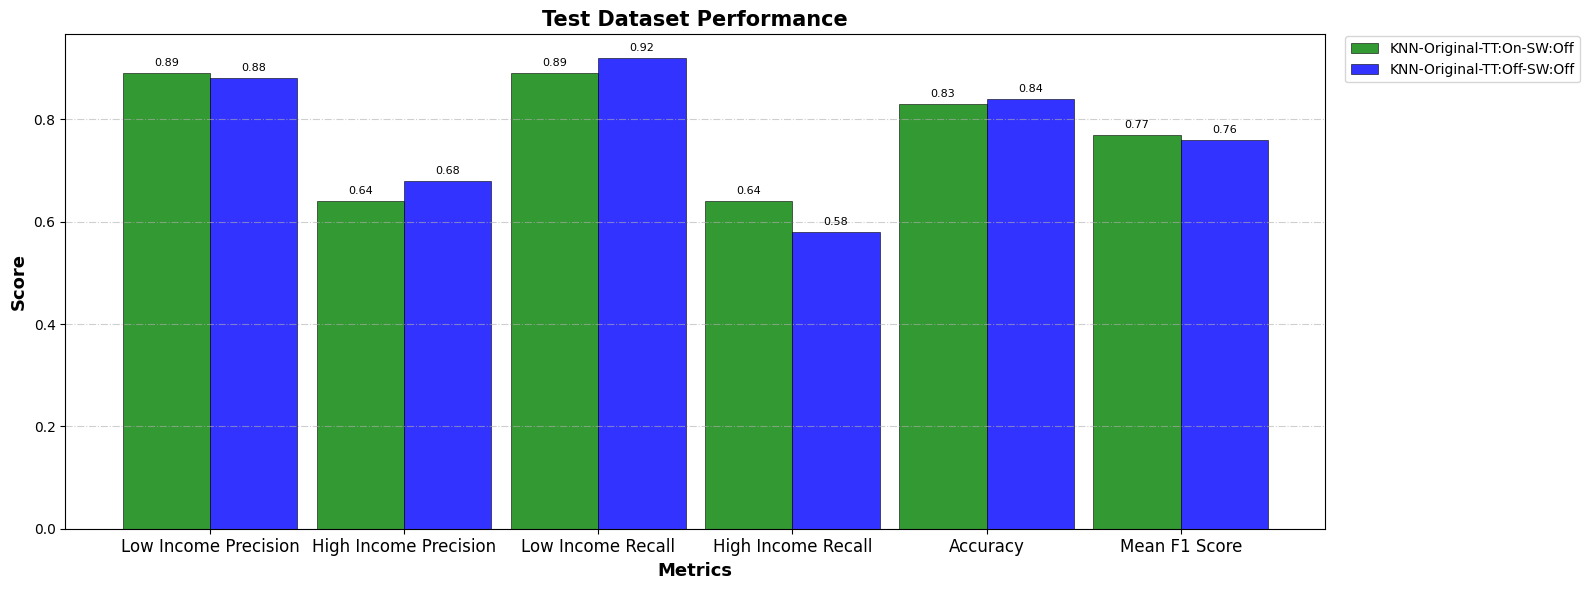

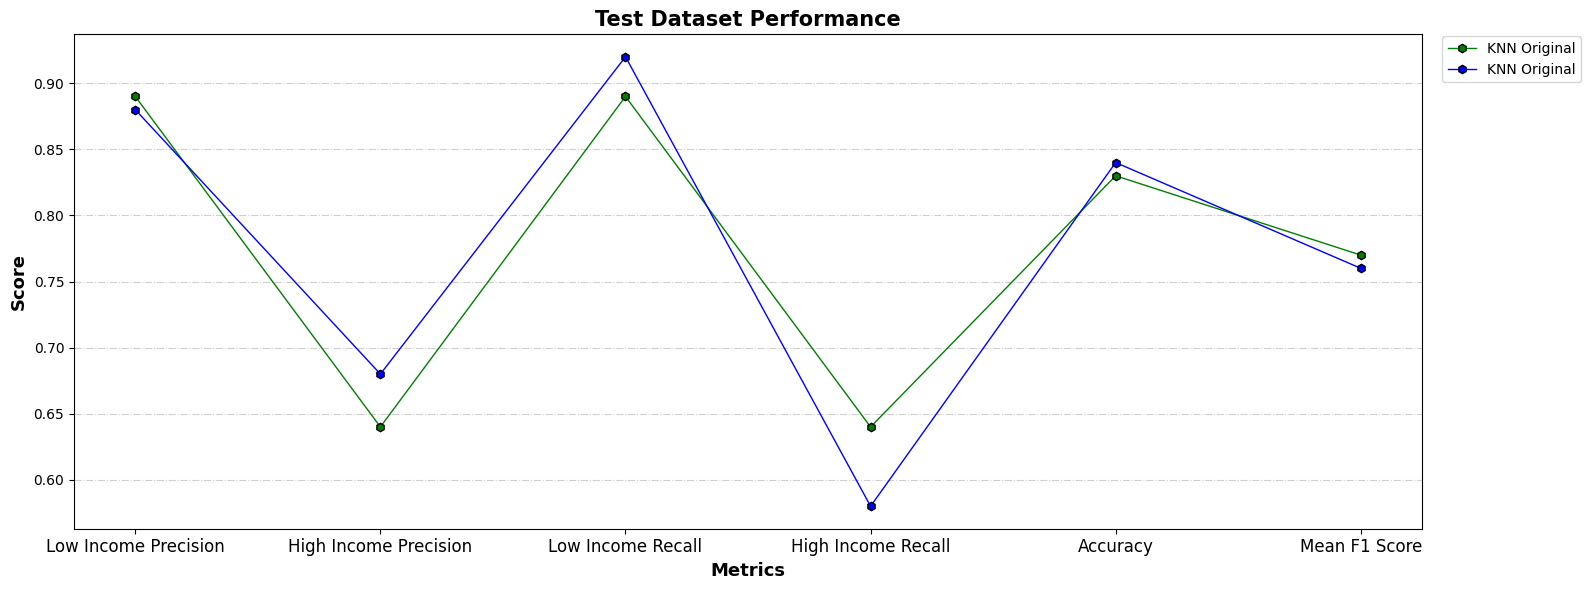

In [58]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'gold', 'violet']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(16, 6))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### SVM RBF

In [59]:
SVM_RBF_model_B = SVC(kernel='rbf', random_state=42 , max_iter=-1, class_weight='balanced')

SVM_RBF_pipe_B = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('SVM_RBF', SVM_RBF_model_B)
])

svm_RBF_C = [0.01, 0.1, 1, 10, 100]
svm_RBF_gamma = ['scale', 'auto', 0.1, 1, 10]


param_grid_SVM_RBF = {
    'SVM_RBF__C': svm_RBF_C,
    'SVM_RBF__gamma' : svm_RBF_gamma,
}

#### Original Data - Sample Weight

In [60]:
SVM_RBF_model_optimized_GS_Original_B = HalvingGridSearchCV(estimator=SVM_RBF_pipe_B, param_grid=param_grid_SVM_RBF, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=-1)
SVM_RBF_model_optimized_GS_Original_B.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 3614
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 25
n_resources: 3614
Fitting 5 folds for each of 25 candidates, totalling 125 fits
----------
iter: 1
n_candidates: 9
n_resources: 10842
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 2
n_candidates: 3
n_resources: 32526
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'SVM_RBF__C': [0.01, 0.1, ...], 'SVM_RBF__gamma': ['scale', 'auto', ...]}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [61]:
best_score_SVM_RBF_Original_B = SVM_RBF_model_optimized_GS_Original_B.best_score_
print(f'SVM RBF Best Score: {best_score_SVM_RBF_Original_B:.2f}')
best_params_SVM_RBF_Original_B = SVM_RBF_model_optimized_GS_Original_B.best_params_
print(f'SVM RBF Best Score: {best_params_SVM_RBF_Original_B}')

Best_SVM_RBF_Original_Estimator_B = SVM_RBF_model_optimized_GS_Original_B.best_estimator_

SVM RBF Best Score: 0.77
SVM RBF Best Score: {'SVM_RBF__C': 100, 'SVM_RBF__gamma': 0.1}


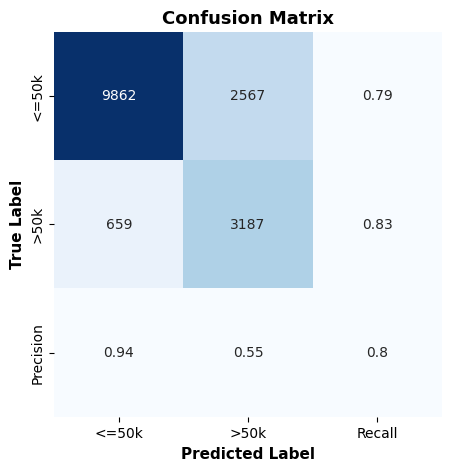

In [62]:
f1_SVM_RBF_original_B, precision_SVM_RBF_original_B, recall_SVM_RBF_original_B, accuracy_SVM_RBF_original_B = display_CM(x_test, y_test, 
                                                                                                         0.5, Best_SVM_RBF_Original_Estimator_B,0)

In [63]:
Score_Information.append({'Model Name': 'SVM', 'DataSet Type': 'Original', 'Low Income Precision': precision_SVM_RBF_original_B[0], 
                          'High Income Precision': precision_SVM_RBF_original_B[1], 'Low Income Recall': recall_SVM_RBF_original_B[0], 
                          'High Income Recall': recall_SVM_RBF_original_B[1], 'Accuracy': accuracy_SVM_RBF_original_B, 
                          'Mean F1 Score': f1_SVM_RBF_original_B, 'Tune Threshold': 'Off', 'Sample Weight': 'On'})

#### Original Data - Non Sample Weight 

In [64]:
SVM_RBF_model_NB = SVC(kernel='rbf', random_state=42 , max_iter=-1)

SVM_RBF_pipe_NB = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('SVM_RBF', SVM_RBF_model_NB)
])

In [65]:
SVM_RBF_model_optimized_GS_Original_NB = HalvingGridSearchCV(estimator=SVM_RBF_pipe_NB, param_grid=param_grid_SVM_RBF, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=-1)
SVM_RBF_model_optimized_GS_Original_NB.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 3614
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 25
n_resources: 3614
Fitting 5 folds for each of 25 candidates, totalling 125 fits
----------
iter: 1
n_candidates: 9
n_resources: 10842
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 2
n_candidates: 3
n_resources: 32526
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'SVM_RBF__C': [0.01, 0.1, ...], 'SVM_RBF__gamma': ['scale', 'auto', ...]}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [66]:
best_score_SVM_RBF_Original_NB = SVM_RBF_model_optimized_GS_Original_NB.best_score_
print(f'SVM RBF Best Score: {best_score_SVM_RBF_Original_NB:.2f}')
best_params_SVM_RBF_Original_NB = SVM_RBF_model_optimized_GS_Original_NB.best_params_
print(f'SVM RBF Best Score: {best_params_SVM_RBF_Original_NB}')

Best_SVM_RBF_Original_NB_Estimator = SVM_RBF_model_optimized_GS_Original_NB.best_estimator_

SVM RBF Best Score: 0.78
SVM RBF Best Score: {'SVM_RBF__C': 100, 'SVM_RBF__gamma': 0.1}


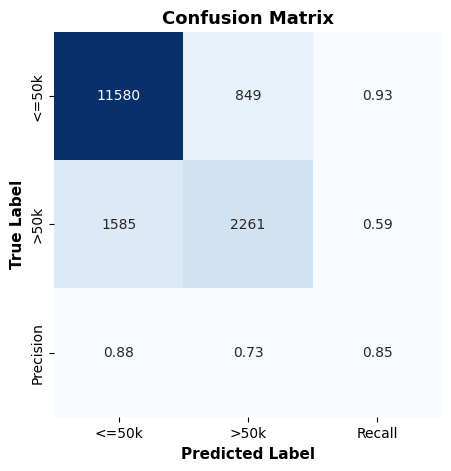

In [67]:
f1_SVM_RBF_original_NB, precision_SVM_RBF_original_NB, recall_SVM_RBF_original_NB, accuracy_SVM_RBF_original_NB = display_CM(x_test, 
                                                                                                                  y_test, 0.5, 
                                                                                                 Best_SVM_RBF_Original_NB_Estimator,0)

In [68]:
Score_Information.append({'Model Name': 'SVM', 'DataSet Type': 'Original', 'Low Income Precision': precision_SVM_RBF_original_NB[0],
                        'High Income Precision': precision_SVM_RBF_original_NB[1], 'Low Income Recall': recall_SVM_RBF_original_NB[0], 
                        'High Income Recall': recall_SVM_RBF_original_NB[1], 'Accuracy': accuracy_SVM_RBF_original_NB, 
                        'Mean F1 Score': f1_SVM_RBF_original_NB, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

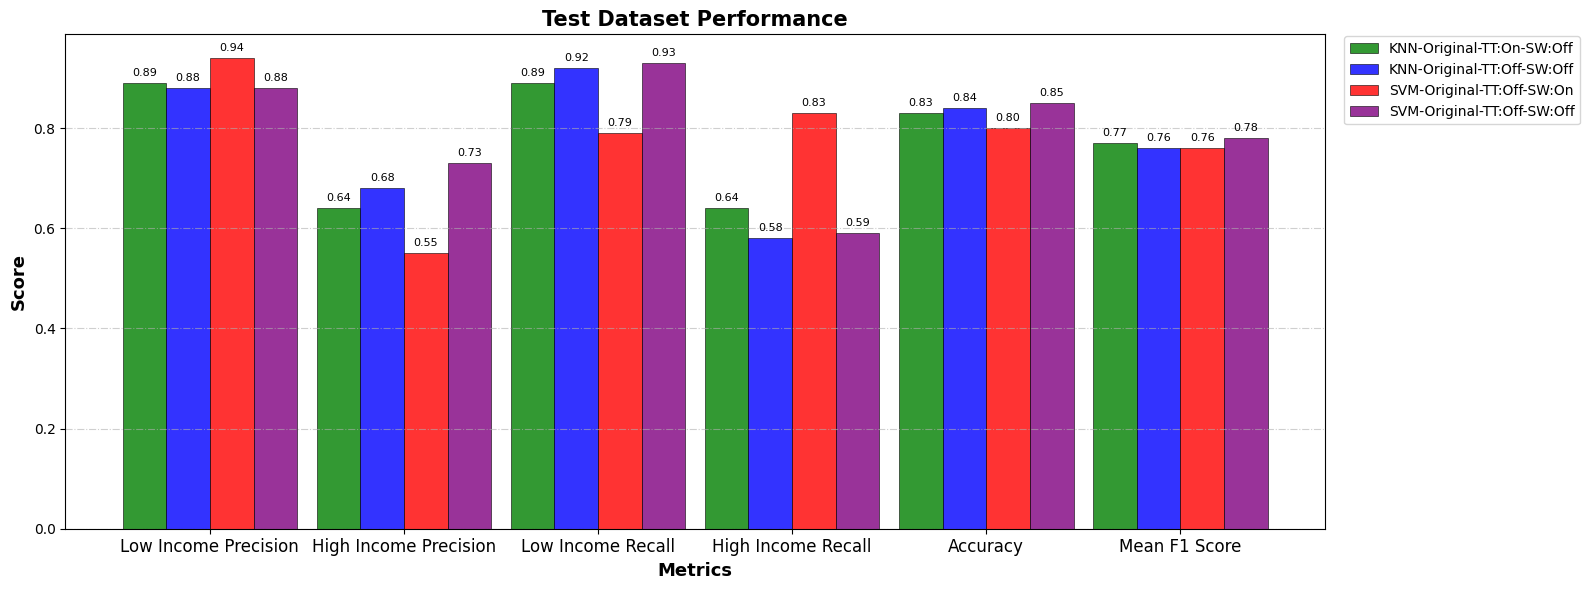

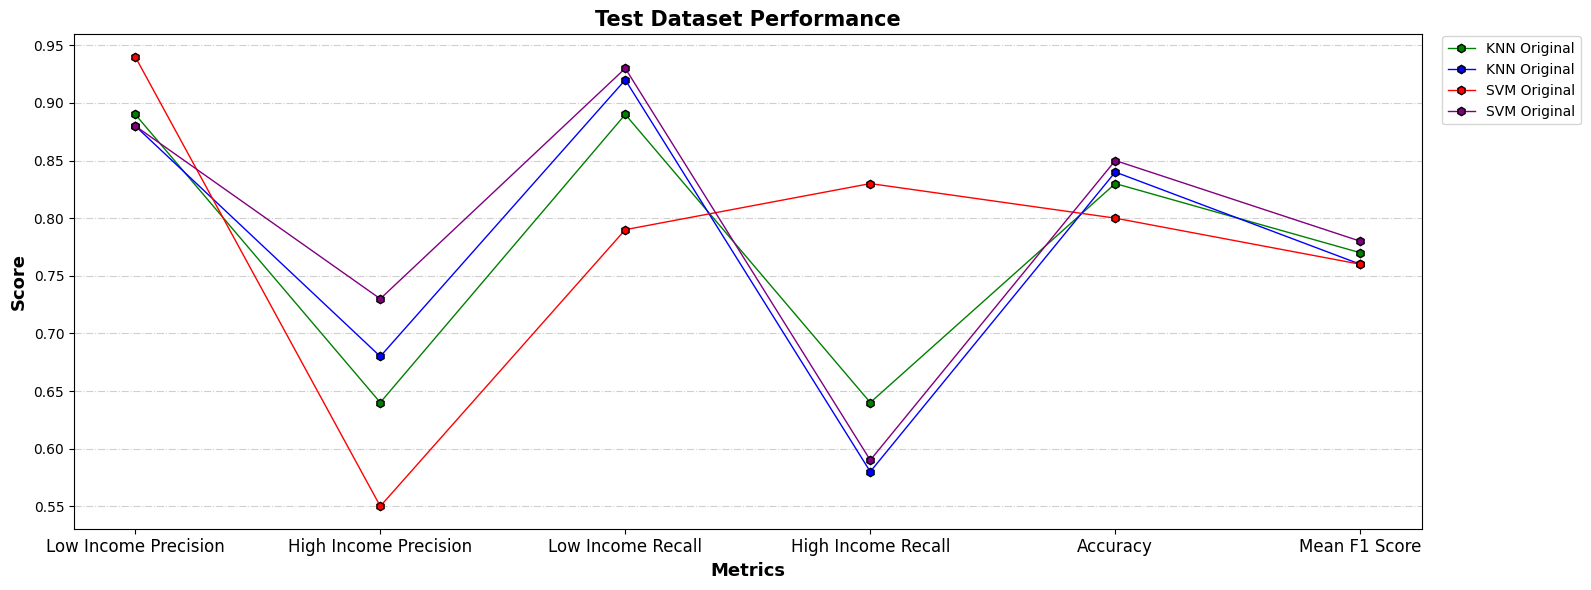

In [69]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'gold', 'violet']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(16, 6))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Random Forest

In [70]:
RF_model_B = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')

RF_N_Estimators = np.arange(start=40, stop=501, step=20)
RF_criterion = ['gini']
min_split = [2,3]
max_depth_RF = [8,16,22]
min_samples_leaf = [1,2]
max_features = ['sqrt', 0.5, 0.3]

param_grid_RF = {
    'n_estimators': RF_N_Estimators,
    'criterion' : RF_criterion,
    'max_features' : max_features,
#     'min_samples_split' : min_split,
    'max_depth' : max_depth_RF
#     'min_samples_leaf' : min_samples_leaf,
}

#### Original Data _ Sample Weight

In [71]:
RF_model_optimized_GS_Original_B = HalvingGridSearchCV(estimator=RF_model_B, param_grid=param_grid_RF, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
RF_model_optimized_GS_Original_B.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 401
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 216
n_resources: 401
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 1
n_candidates: 72
n_resources: 1203
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 2
n_candidates: 24
n_resources: 3609
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 3
n_candidates: 8
n_resources: 10827
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 4
n_candidates: 3
n_resources: 32481
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini'], 'max_depth': [8, 16, ...], 'max_features': ['sqrt', 0.5, ...], 'n_estimators': array([ 40, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [72]:
best_score_RF_Original_B = RF_model_optimized_GS_Original_B.best_score_
print(f'RF Best Score: {best_score_RF_Original_B:.2f}')
best_params_RF_Original_B = RF_model_optimized_GS_Original_B.best_params_
print(f'RF Best Score: {best_params_RF_Original_B}')

Best_RF_Original_B_Estimator = RF_model_optimized_GS_Original_B.best_estimator_

RF Best Score: 0.77
RF Best Score: {'criterion': 'gini', 'max_depth': 8, 'max_features': 0.5, 'n_estimators': 420}


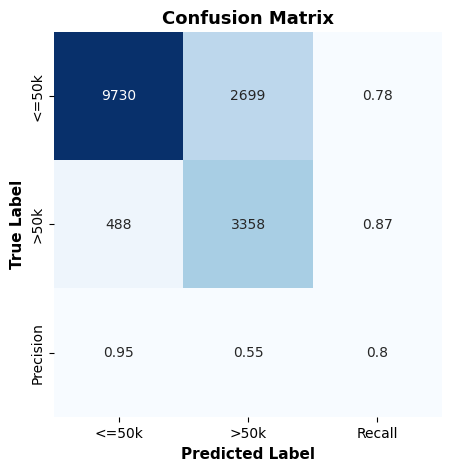

In [73]:
f1_RF_original_B, precision_RF_original_B, recall_RF_original_B, accuracy_RF_original_B = display_CM(x_test, y_test, 
                                                                                             0.5, Best_RF_Original_B_Estimator,0)

In [74]:
Score_Information.append({'Model Name': 'RF', 'DataSet Type': 'Original', 'Low Income Precision': precision_RF_original_B[0], 
                          'High Income Precision': precision_RF_original_B[1], 'Low Income Recall': recall_RF_original_B[0], 
                          'High Income Recall': recall_RF_original_B[1], 'Accuracy': accuracy_RF_original_B, 
                          'Mean F1 Score': f1_RF_original_B, 'Tune Threshold': 'Off', 'Sample Weight': 'On'})

#### Original Data - Non Sample Weight

In [75]:
RF_model_NB = RandomForestClassifier(random_state=42, n_jobs=-1)

RF_model_optimized_GS_Original_NB = HalvingGridSearchCV(estimator=RF_model_NB, param_grid=param_grid_RF, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
RF_model_optimized_GS_Original_NB.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 401
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 216
n_resources: 401
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 1
n_candidates: 72
n_resources: 1203
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 2
n_candidates: 24
n_resources: 3609
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 3
n_candidates: 8
n_resources: 10827
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 4
n_candidates: 3
n_resources: 32481
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini'], 'max_depth': [8, 16, ...], 'max_features': ['sqrt', 0.5, ...], 'n_estimators': array([ 40, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [76]:
best_score_RF_Original_NB = RF_model_optimized_GS_Original_NB.best_score_
print(f'RF Best Score: {best_score_RF_Original_NB:.2f}')
best_params_RF_Original_NB = RF_model_optimized_GS_Original_NB.best_params_
print(f'RF Best Score: {best_params_RF_Original_NB}')

Best_RF_Original_NB_Estimator = RF_model_optimized_GS_Original_NB.best_estimator_

RF Best Score: 0.78
RF Best Score: {'criterion': 'gini', 'max_depth': 8, 'max_features': 0.5, 'n_estimators': 100}


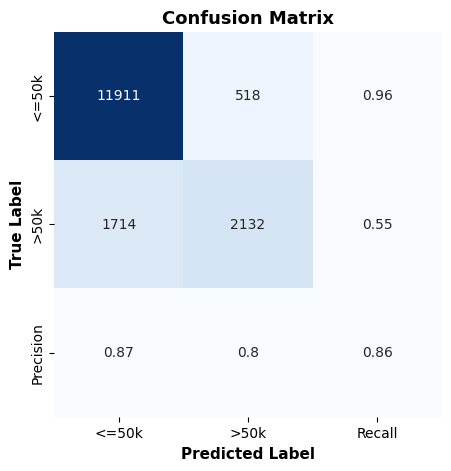

In [77]:
f1_RF_original_NB, precision_RF_original_NB, recall_RF_original_NB, accuracy_RF_original_NB = display_CM(x_test, y_test, 
                                                                                             0.5, Best_RF_Original_NB_Estimator,0)

In [78]:
Score_Information.append({'Model Name': 'RF', 'DataSet Type': 'Original', 'Low Income Precision': precision_RF_original_NB[0], 
                          'High Income Precision': precision_RF_original_NB[1], 'Low Income Recall': recall_RF_original_NB[0], 
                          'High Income Recall': recall_RF_original_NB[1], 'Accuracy': accuracy_RF_original_NB, 
                          'Mean F1 Score': f1_RF_original_NB, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

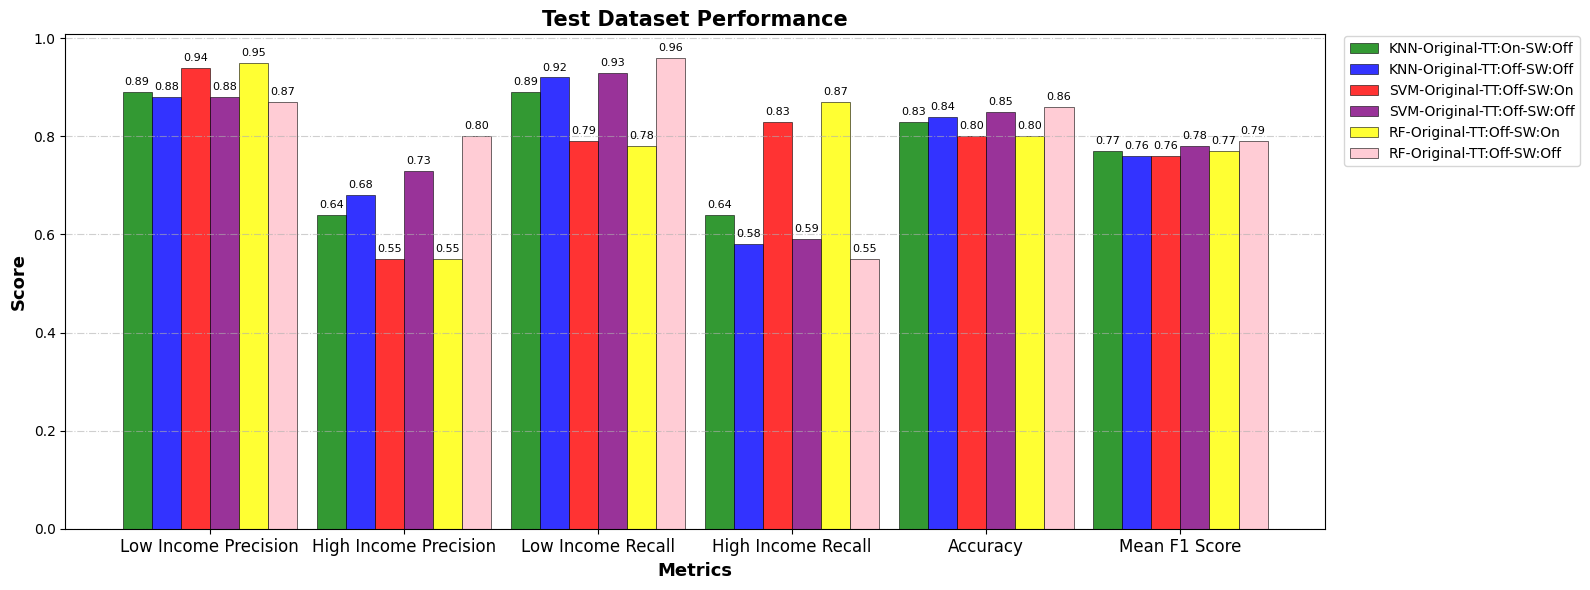

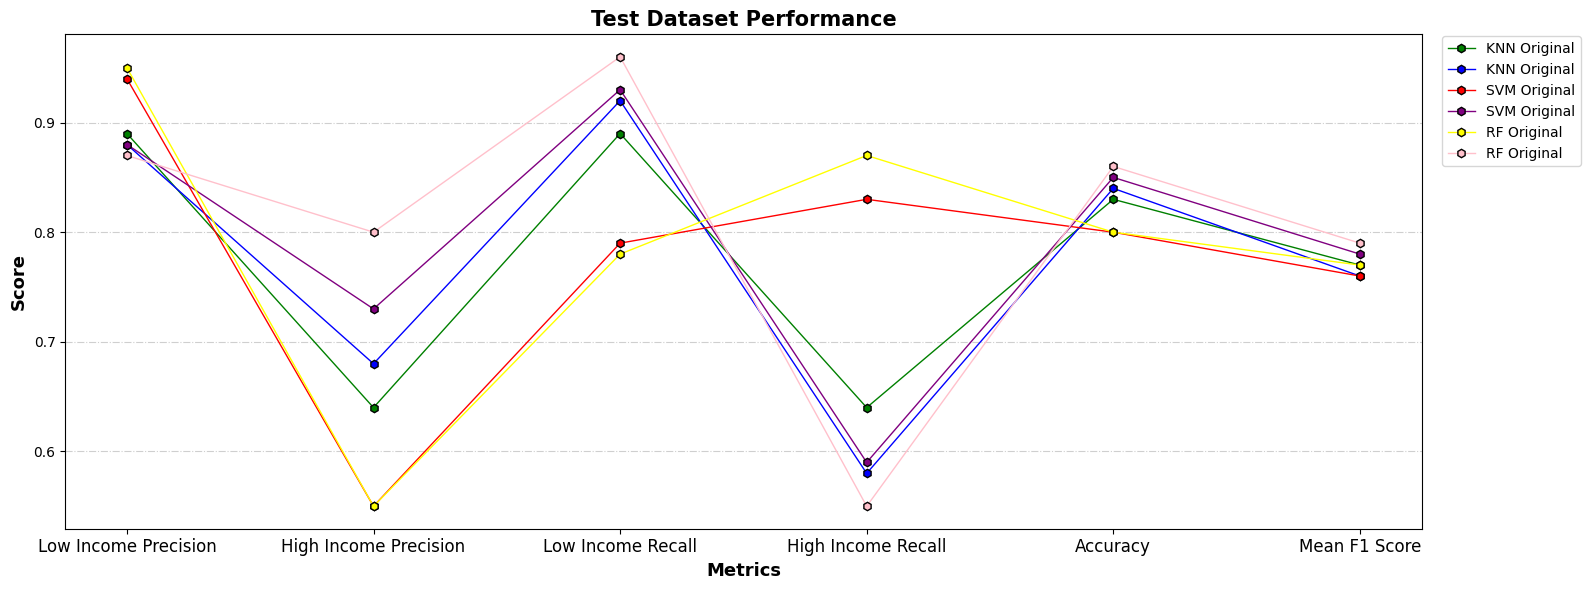

In [79]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'chocolate', 'skyblue', 'gray', 'lime']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(16, 6))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Balanced RandomForestClassifier

In [80]:
BRF_model = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)

BRF_N_Estimators = np.arange(start=40, stop=501, step=20)
BRF_criterion = ['gini']
min_split_BRF = [2,3]
max_depth_BRF = [8,16,22]
min_samples_leaf_BRF = [1,2]
max_features_BRF = ['sqrt', 0.5, 0.3]

param_grid_BRF = {
    'n_estimators': BRF_N_Estimators,
    'criterion' : BRF_criterion,
    'max_features' : max_features_BRF,
#     'min_samples_split' : min_split_BRF,
    'max_depth' : max_depth_BRF
#     'min_samples_leaf' : min_samples_leaf_BRF,
}

#### Original Data - Non Tune Threshold

In [81]:
BRF_model_optimized_GS_original_NTT = HalvingGridSearchCV(estimator=BRF_model, param_grid=param_grid_BRF, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
BRF_model_optimized_GS_original_NTT.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 401
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 216
n_resources: 401
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 1
n_candidates: 72
n_resources: 1203
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 2
n_candidates: 24
n_resources: 3609
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 3
n_candidates: 8
n_resources: 10827
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 4
n_candidates: 3
n_resources: 32481
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,BalancedRando...ndom_state=42)
,param_grid,"{'criterion': ['gini'], 'max_depth': [8, 16, ...], 'max_features': ['sqrt', 0.5, ...], 'n_estimators': array([ 40, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [82]:
best_score_BRF_original_NTT = BRF_model_optimized_GS_original_NTT.best_score_
print(f'BRF Best Score: {best_score_BRF_original_NTT:.2f}')
best_params_BRF_original_NTT = BRF_model_optimized_GS_original_NTT.best_params_
print(f'BRF Best Score: {best_params_BRF_original_NTT}')

Best_BRF_original_NTT_Estimator = BRF_model_optimized_GS_original_NTT.best_estimator_

BRF Best Score: 0.79
BRF Best Score: {'criterion': 'gini', 'max_depth': 22, 'max_features': 'sqrt', 'n_estimators': 320}


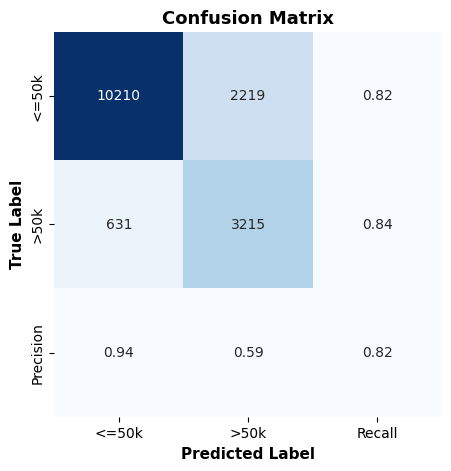

In [83]:
f1_BRF_original_NTT, precision_BRF_original_NTT, recall_BRF_original_NTT, accuracy_BRF_original_NTT = display_CM(x_test, y_test, 
                                                                                             0.5, Best_BRF_original_NTT_Estimator,0)

In [84]:
Score_Information.append({'Model Name': 'BRF', 'DataSet Type': 'Original', 'Low Income Precision': precision_BRF_original_NTT[0], 
                          'High Income Precision': precision_BRF_original_NTT[1], 'Low Income Recall': recall_BRF_original_NTT[0], 
                          'High Income Recall': recall_BRF_original_NTT[1], 'Accuracy': accuracy_BRF_original_NTT, 
                          'Mean F1 Score': f1_BRF_original_NTT, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

#### Original Data - Tune Threshold

In [85]:
best_score_BRF_original_TT = BRF_model_optimized_GS_original_NTT.best_score_
print(f'BRF Best Score: {best_score_BRF_original_TT:.2f}')
best_params_BRF_original_TT = BRF_model_optimized_GS_original_NTT.best_params_
print(f'BRF Best Score: {best_params_BRF_original_TT}')

Best_BRF_original_TT_Estimator = BRF_model_optimized_GS_original_NTT.best_estimator_

BRF Best Score: 0.79
BRF Best Score: {'criterion': 'gini', 'max_depth': 22, 'max_features': 'sqrt', 'n_estimators': 320}


Best Threshold : 0.65
Best F1 Score for high income : 0.86


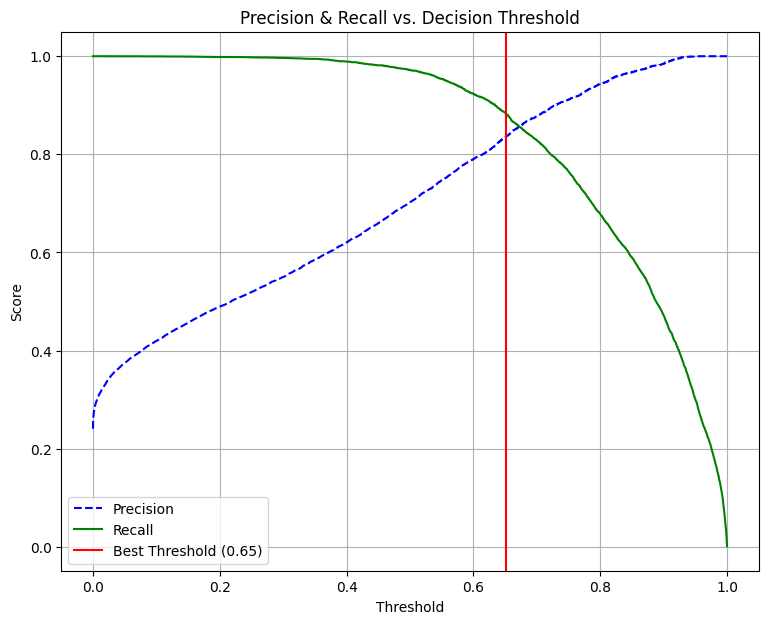

In [86]:
best_threshold_BRF_original_TT, y_proba_BRF_original_TT = best_threshold(x_train_original, y_train_original, 
                                                                         Best_BRF_original_TT_Estimator)

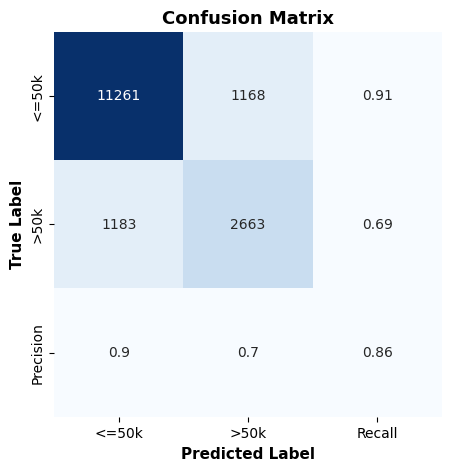

In [87]:
f1_BRF_original_TT, precision_BRF_original_TT, recall_BRF_original_TT, accuracy_BRF_original_TT = display_CM(x_test, y_test, 
                                                                                             best_threshold_BRF_original_TT, 
                                                                                             Best_BRF_original_TT_Estimator,1)

In [88]:
Score_Information.append({'Model Name': 'BRF', 'DataSet Type': 'Original', 'Low Income Precision': precision_BRF_original_TT[0], 
                          'High Income Precision': precision_BRF_original_TT[1], 'Low Income Recall': recall_BRF_original_TT[0], 
                          'High Income Recall': recall_BRF_original_TT[1], 'Accuracy': accuracy_BRF_original_TT, 
                          'Mean F1 Score': f1_BRF_original_TT, 'Tune Threshold': 'On', 'Sample Weight': 'Off'})

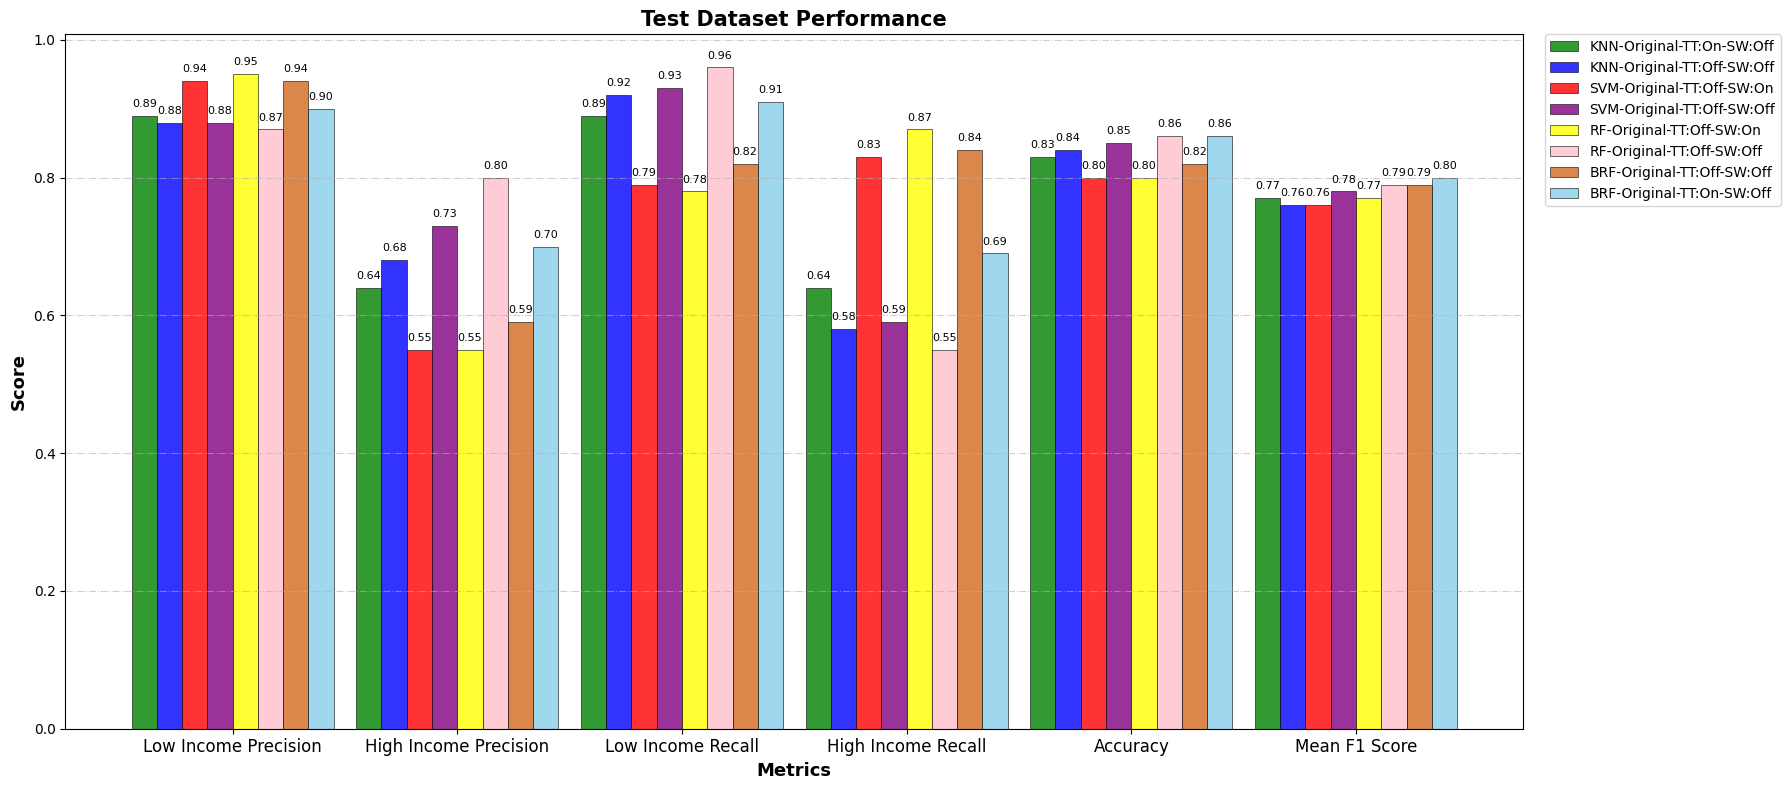

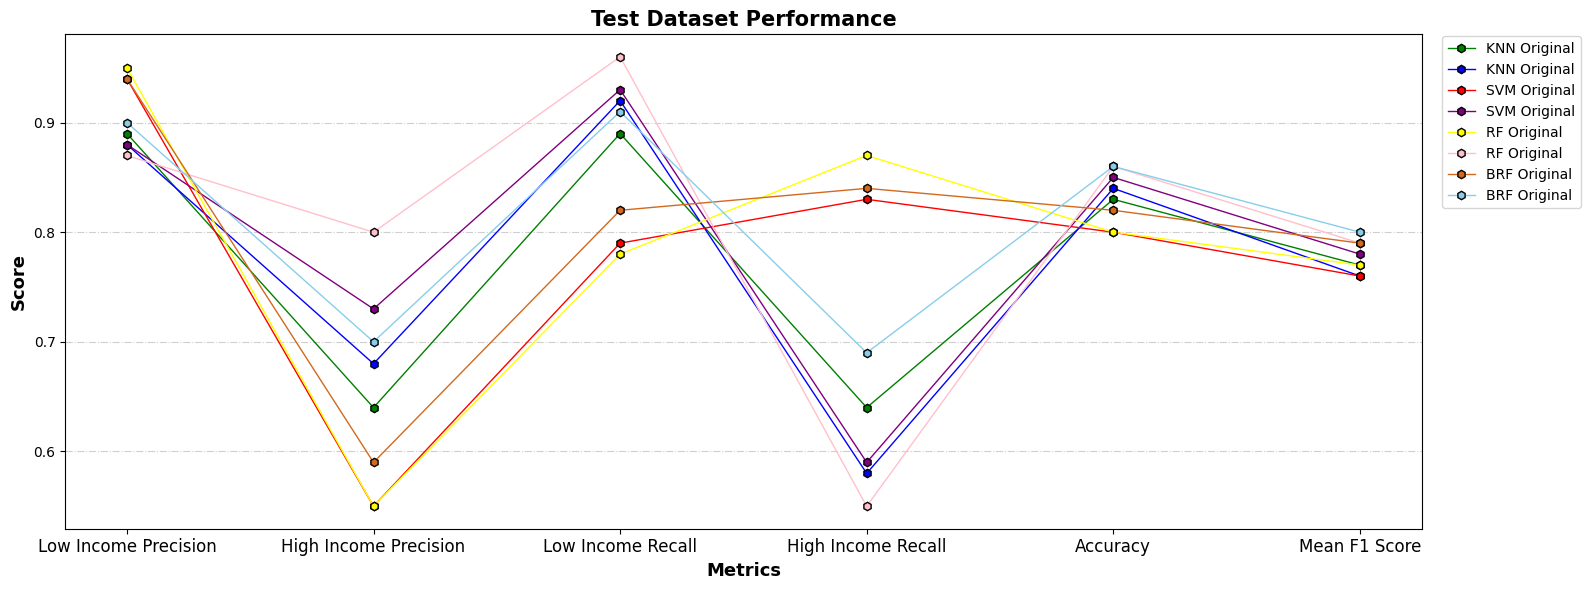

In [89]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'chocolate', 'skyblue', 'gray', 'lime']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(18, 8))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)       # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Gradient Boosting

In [90]:
GBC_model = GradientBoostingClassifier(random_state=42)

GBC_N_Estimators = np.arange(start=40, stop=501, step=20)
GBC_learning_rate = [0.1, 0.2, 0.3, 0.5]
min_split_GB = [2,3]
max_depth_GB = [3,5,8,12]
min_samples_leaf_GB = [1,2]

param_grid_GB = {
    'n_estimators': GBC_N_Estimators,
    'learning_rate' : GBC_learning_rate,
    # 'min_samples_split' : min_split_GB,
    'max_depth' : max_depth_GB,
    # 'min_samples_leaf' : min_samples_leaf_GB,
}


#### Original Data - Non Tune Threshold

In [91]:
GBC_model_optimized_GS_Original_NTT = HalvingGridSearchCV(estimator=GBC_model, param_grid=param_grid_GB, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
GBC_model_optimized_GS_Original_NTT.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 133
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 384
n_resources: 133
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
----------
iter: 1
n_candidates: 128
n_resources: 399
Fitting 5 folds for each of 128 candidates, totalling 640 fits
----------
iter: 2
n_candidates: 43
n_resources: 1197
Fitting 5 folds for each of 43 candidates, totalling 215 fits
----------
iter: 3
n_candidates: 15
n_resources: 3591
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 4
n_candidates: 5
n_resources: 10773
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 5
n_candidates: 2
n_resources: 32319
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.1, 0.2, ...], 'max_depth': [3, 5, ...], 'n_estimators': array([ 40, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [92]:
best_score_GB_original_NTT = GBC_model_optimized_GS_Original_NTT.best_score_
print(f'GB Best Score: {best_score_GB_original_NTT:.2f}')
best_params_GB_original_NTT = GBC_model_optimized_GS_Original_NTT.best_params_
print(f'GB Best Score: {best_params_GB_original_NTT}')

Best_GB_original_NTT_Estimator = GBC_model_optimized_GS_Original_NTT.best_estimator_

GB Best Score: 0.81
GB Best Score: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 280}


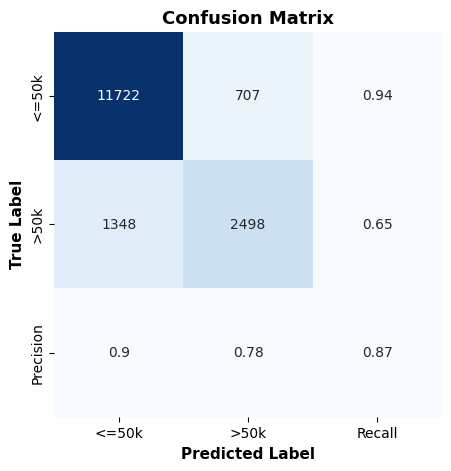

In [93]:
f1_GB_original_NTT, precision_GB_original_NTT, recall_GB_original_NTT, accuracy_GB_original_NTT = display_CM(x_test, y_test, 
                                                                                             0.5, Best_GB_original_NTT_Estimator,0)

In [94]:
Score_Information.append({'Model Name': 'GB', 'DataSet Type': 'Original', 'Low Income Precision': precision_GB_original_NTT[0], 
                          'High Income Precision': precision_GB_original_NTT[1], 'Low Income Recall': recall_GB_original_NTT[0], 
                          'High Income Recall': recall_GB_original_NTT[1], 'Accuracy': accuracy_GB_original_NTT, 
                          'Mean F1 Score': f1_GB_original_NTT, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

#### Original Data - Tune Threshold

In [95]:
best_score_GB_original_TT = GBC_model_optimized_GS_Original_NTT.best_score_
print(f'GB Best Score: {best_score_GB_original_TT:.2f}')
best_params_GB_original_TT = GBC_model_optimized_GS_Original_NTT.best_params_
print(f'GB Best Score: {best_params_GB_original_TT}')

Best_GB_original_TT_Estimator = GBC_model_optimized_GS_Original_NTT.best_estimator_

GB Best Score: 0.81
GB Best Score: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 280}


Best Threshold : 0.39
Best F1 Score for high income : 0.75


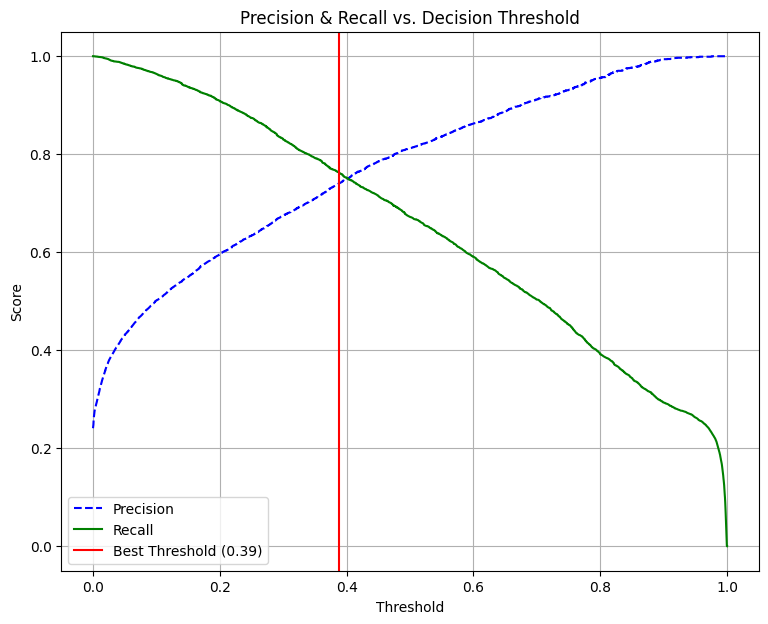

In [96]:
best_threshold_GB_original_TT, y_proba_GB_original_TT = best_threshold(x_train_original, y_train_original, 
                                                                       Best_GB_original_TT_Estimator)

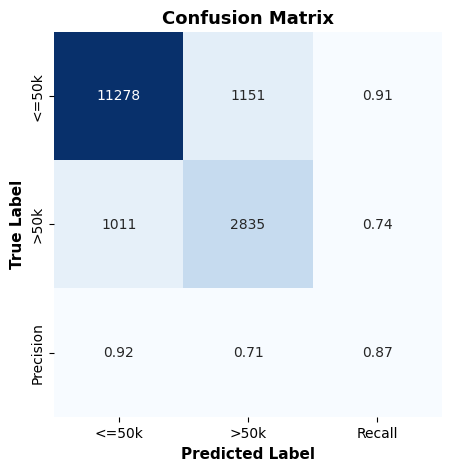

In [97]:
f1_GB_original_TT, precision_GB_original_TT, recall_GB_original_TT, accuracy_GB_original_TT = display_CM(x_test, y_test, 
                                                                                             best_threshold_GB_original_TT, 
                                                                                             Best_GB_original_TT_Estimator, 1)

In [98]:
Score_Information.append({'Model Name': 'GB', 'DataSet Type': 'Original', 'Low Income Precision': precision_GB_original_TT[0], 
                          'High Income Precision': precision_GB_original_TT[1], 'Low Income Recall': recall_GB_original_TT[0], 
                          'High Income Recall': recall_GB_original_TT[1], 'Accuracy': accuracy_GB_original_TT, 
                          'Mean F1 Score': f1_GB_original_TT, 'Tune Threshold': 'On', 'Sample Weight': 'Off'})

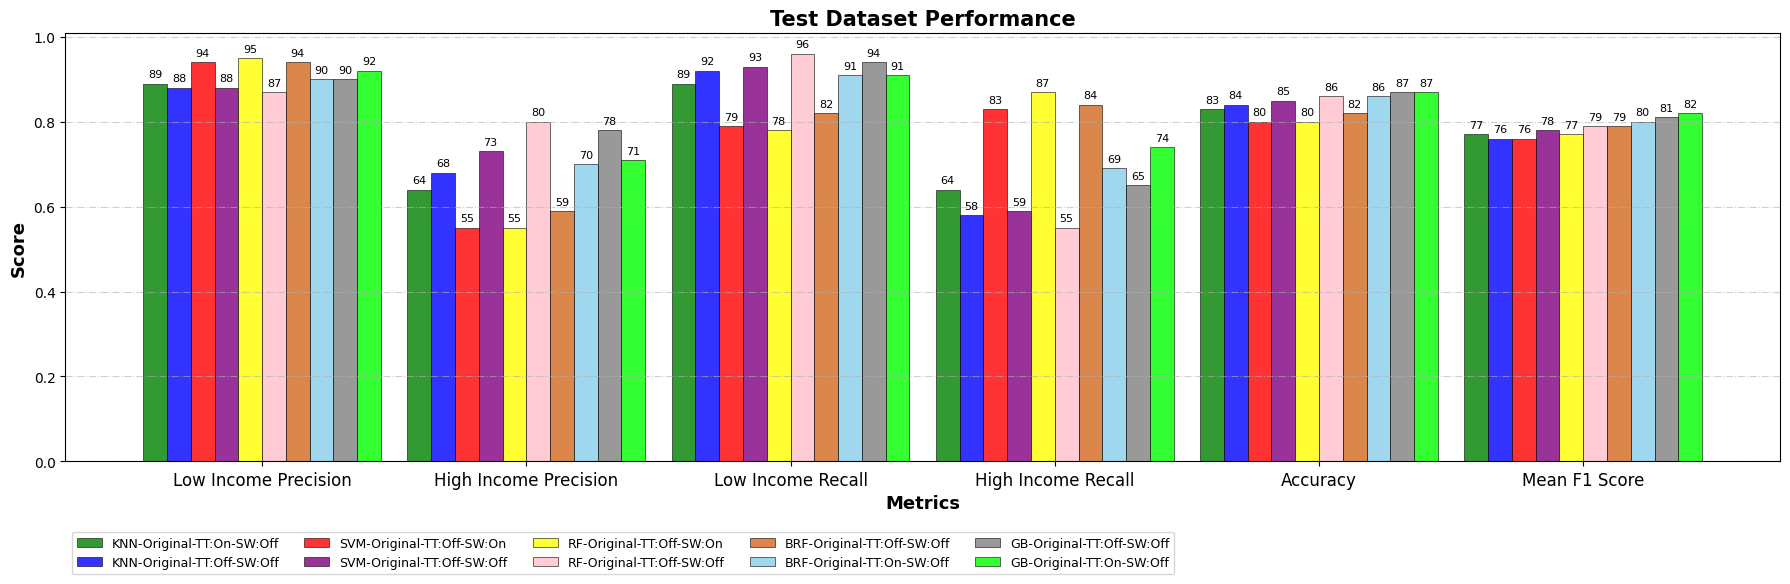

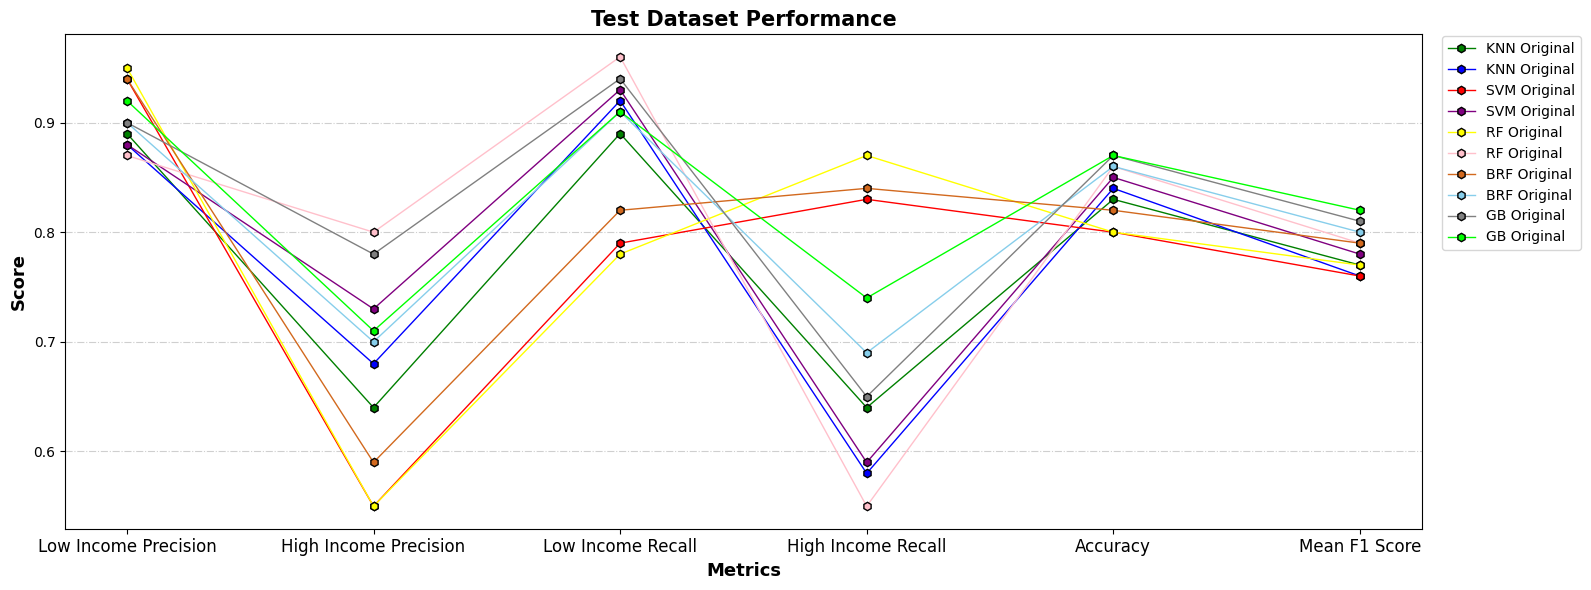

In [99]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'chocolate', 'skyblue', 'gray', 'lime']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(18, 6))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val*100:.0f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
ncol = 5 # Number of labels per line
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left', 
           ncol=ncol, fontsize=9, frameon=True)    # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Neural Networks

In [100]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))
# CELL 1
import os

# This line MUST be executed before TensorFlow is imported for the first time.
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Now, this check will correctly show that no GPUs are visible.
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [101]:
from keras.layers import Layer

class RBFLayer(Layer):
    def __init__(self, sigma, **kwargs):
        super().__init__(**kwargs)
        self.sigma = sigma

    def call(self, inputs):
        return tf.exp(-tf.square(inputs) / (2.0 * tf.square(self.sigma)))
    

In [102]:
def NN_SVM(hp):

    num_hidden_layer = hp.Choice('num_hidden_layer', [1,2])
    u_1 = hp.Choice('first_hidden_layer', [30,40,50,60,70,80,90])
    u_2 = hp.Choice('second_hidden_layer', [20,30,40,50,60])
    dropout = hp.Float('dropout', 0.1, 0.21, step=0.1)
    lr = hp.Choice('learning_rate', [1e-3])
    sigma = hp.Choice('sigma', [0.1,1.0,10.0])

    model = Sequential()
    model.add(Input(shape=(x_train_smotetomek.shape[1],)))

    model.add(Dense(units=u_1, use_bias=False, activation=None))
    model.add(BatchNormalization())
    #model.add(Activation('tanh'))
    model.add(RBFLayer(sigma=sigma))
    model.add(Dropout(rate=dropout, seed=42))

    if num_hidden_layer >= 2:
        model.add(Dense(units=u_2, use_bias=False, activation=None))
        model.add(BatchNormalization())
        #model.add(Activation('tanh'))
        model.add(RBFLayer(sigma=sigma))
        model.add(Dropout(rate=dropout, seed=42))

    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer = Adam(learning_rate=lr), loss='binary_crossentropy', 
                  metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

    return model


### Original Data - Tune Threshold

In [103]:
tuner_NN_RBF_Original_TT = kt.Hyperband(hypermodel=NN_SVM,
                     objective=kt.Objective('val_pr_auc', direction='max'),    
                     max_epochs=60,
                     factor=2,                
                     hyperband_iterations=1,  
                     directory='./tuner',
                     project_name='NN_RBF',
                     overwrite=False
)
early_stop = EarlyStopping(monitor='val_pr_auc', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

INFO:tensorflow:Reloading Oracle from existing project ./tuner\NN_RBF\oracle.json
INFO:tensorflow:Reloading Tuner from ./tuner\NN_RBF\tuner0.json


In [99]:
tuner_NN_RBF_Original_TT.search(
    x_train_original_norm,
    y_train_original,
    validation_split=0.15,
    verbose=2,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 186 Complete [00h 03m 23s]
val_pr_auc: 0.7551696300506592

Best val_pr_auc So Far: 0.765001118183136
Total elapsed time: 02h 00m 40s
INFO:tensorflow:Oracle triggered exit


In [104]:
best_hp_NN_RBF_Original_TT = tuner_NN_RBF_Original_TT.get_best_hyperparameters(num_trials=1)[0]
for keys,values in best_hp_NN_RBF_Original_TT.values.items():
    print(f'{keys} : {values}')

num_hidden_layer : 1
first_hidden_layer : 80
second_hidden_layer : 30
dropout : 0.1
learning_rate : 0.001
sigma : 1.0
tuner/epochs : 60
tuner/initial_epoch : 30
tuner/bracket : 5
tuner/round : 5
tuner/trial_id : f89fd6d48ea87a44b90223421b9caf0a


In [105]:
model_RBFNN_Original_TT = tuner_NN_RBF_Original_TT.hypermodel.build(best_hp_NN_RBF_Original_TT)
model_RBFNN_Original_TT.fit(x_train_original_norm, y_train_original, epochs=200, batch_size=64, validation_split=0.15, callbacks=[early_stop,reduce_lr])

Epoch 1/200
433/433 [==============================] - 6s 8ms/step - loss: 0.4462 - pr_auc: 0.5446 - val_loss: 0.3472 - val_pr_auc: 0.7341 - lr: 0.0010
Epoch 2/200
433/433 [==============================] - 3s 8ms/step - loss: 0.3570 - pr_auc: 0.7161 - val_loss: 0.3261 - val_pr_auc: 0.7441 - lr: 0.0010
Epoch 3/200
433/433 [==============================] - 3s 7ms/step - loss: 0.3458 - pr_auc: 0.7244 - val_loss: 0.3227 - val_pr_auc: 0.7446 - lr: 0.0010
Epoch 4/200
433/433 [==============================] - 3s 7ms/step - loss: 0.3400 - pr_auc: 0.7343 - val_loss: 0.3140 - val_pr_auc: 0.7527 - lr: 0.0010
Epoch 5/200
433/433 [==============================] - 3s 7ms/step - loss: 0.3362 - pr_auc: 0.7392 - val_loss: 0.3123 - val_pr_auc: 0.7560 - lr: 0.0010
Epoch 6/200
433/433 [==============================] - 3s 7ms/step - loss: 0.3332 - pr_auc: 0.7425 - val_loss: 0.3113 - val_pr_auc: 0.7556 - lr: 0.0010
Epoch 7/200
433/433 [==============================] - 3s 7ms/step - loss: 0.3325 - pr_a

In [106]:
model_RBFNN_Original_TT.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 80)                2640      
                                                                 
 batch_normalization_1 (Batc  (None, 80)               320       
 hNormalization)                                                 
                                                                 
 rbf_layer_1 (RBFLayer)      (None, 80)                0         
                                                                 
 dropout_1 (Dropout)         (None, 80)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 81        
                                                                 
Total params: 3,041
Trainable params: 2,881
Non-trainable params: 160
__________________________________________________

In [107]:
def best_threshold_NN(X,Y,best_estimator):
    
    y_prob = best_estimator.predict(X)
    precisions, recalls, thresholds = precision_recall_curve(column_or_1d(Y), y_prob)

    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print(f'Best Threshold : {best_threshold:.2f}')
    print(f'Best F1 Score for high income : {f1_scores[best_idx]:.2f}')

    plt.figure(figsize=(9,7))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', linestyle="--")
    plt.plot(thresholds, recalls[:-1], label='Recall', color='green', linestyle="-")
    plt.axvline(best_threshold, color='red', label=f'Best Threshold ({best_threshold:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision & Recall vs. Decision Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_threshold, y_prob

def display_CM_NN(X,Y,best_threshold,best_estimator):

    y_prob = best_estimator.predict(X)
    y_pred = (y_prob > best_threshold).astype(int)

    CM_Test = confusion_matrix(column_or_1d(Y),column_or_1d(y_pred))
    pre_score = np.round(precision_score(column_or_1d(Y),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    rec_score = np.round(recall_score(column_or_1d(Y),column_or_1d(y_pred), average=None, pos_label=1), decimals=2)
    acc_score = np.round(accuracy_score(column_or_1d(Y),column_or_1d(y_pred)), decimals=2)
    f1 = np.round(f1_score(column_or_1d(Y),column_or_1d(y_pred), average='macro'), decimals=2)
    CM = np.concatenate((np.vstack((CM_Test,pre_score)),np.hstack((rec_score,acc_score)).reshape(3,1)), axis=1)
    df_CM = pd.DataFrame(CM, index=['<=50k', '>50k', 'Precision'], columns=['<=50k', '>50k', 'Recall'])

    plt.figure(figsize=(5,5))
    sns.heatmap(df_CM, annot=True, cbar=False, cmap=plt.cm.Blues, fmt='.5g')
    plt.xlabel('Predicted Label', fontsize=11, weight='bold')
    plt.ylabel('True Label', fontsize=11, weight='bold')
    plt.title('Confusion Matrix', fontsize=13, weight='bold')
    plt.show()

    return f1, pre_score, rec_score, acc_score

1017/1017 [==============================] - 2s 1ms/step
Best Threshold : 0.31
Best F1 Score for high income : 0.71


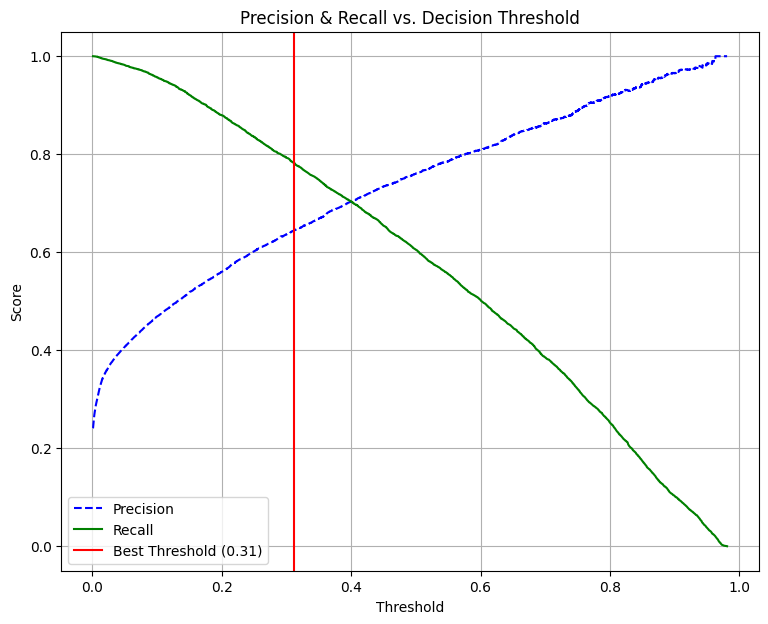

In [108]:
best_threshold_RBF_NN_original_TT, y_proba_RBF_NN_original_TT = best_threshold_NN(x_train_original_norm, y_train_original,
                                                                                   model_RBFNN_Original_TT)

509/509 [==============================] - 1s 2ms/step


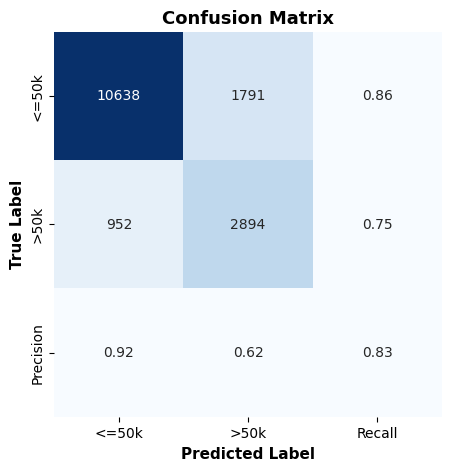

In [109]:
f1_RBF_NN_original_TT, precision_RBF_NN_original_TT, recall_RBF_NN_original_TT, accuracy_RBF_NN_original_TT = display_CM_NN(x_test_norm, y_test, 
                                                                                             best_threshold_RBF_NN_original_TT, 
                                                                                             model_RBFNN_Original_TT)

In [110]:
Score_Information.append({'Model Name': 'RBF NN', 'DataSet Type': 'Original', 'Low Income Precision': precision_RBF_NN_original_TT[0], 
                          'High Income Precision': precision_RBF_NN_original_TT[1], 'Low Income Recall': recall_RBF_NN_original_TT[0], 
                          'High Income Recall': recall_RBF_NN_original_TT[1], 'Accuracy': accuracy_RBF_NN_original_TT, 
                          'Mean F1 Score': f1_RBF_NN_original_TT, 'Tune Threshold': 'On', 'Sample Weight': 'Off'})

### Original Data - Non Tune Threshold

In [111]:
model_RBFNN_Original_NTT = tf.keras.models.Sequential()
for layer in model_RBFNN_Original_TT.layers:
    if hasattr(layer, 'sigma'):  # Check if it's custom layer
        # Recreate custom layer with same parameters
        new_layer = RBFLayer(sigma=layer.sigma)
        model_RBFNN_Original_NTT.add(new_layer)
    else:
        # using config for standard layers
        config = layer.get_config()
        new_layer = type(layer).from_config(config)
        model_RBFNN_Original_NTT.add(new_layer)
        
model_RBFNN_Original_NTT.build(model_RBFNN_Original_TT.input_shape)
model_RBFNN_Original_NTT.set_weights(model_RBFNN_Original_TT.get_weights())

In [112]:
model_RBFNN_Original_NTT.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 80)                2640      
                                                                 
 batch_normalization_1 (Batc  (None, 80)               320       
 hNormalization)                                                 
                                                                 
 rbf_layer_2 (RBFLayer)      (None, 80)                0         
                                                                 
 dropout_1 (Dropout)         (None, 80)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 81        
                                                                 
Total params: 3,041
Trainable params: 2,881
Non-trainable params: 160
__________________________________________________

1017/1017 [==============================] - 1s 1ms/step
Best Threshold : 0.31
Best F1 Score for high income : 0.71


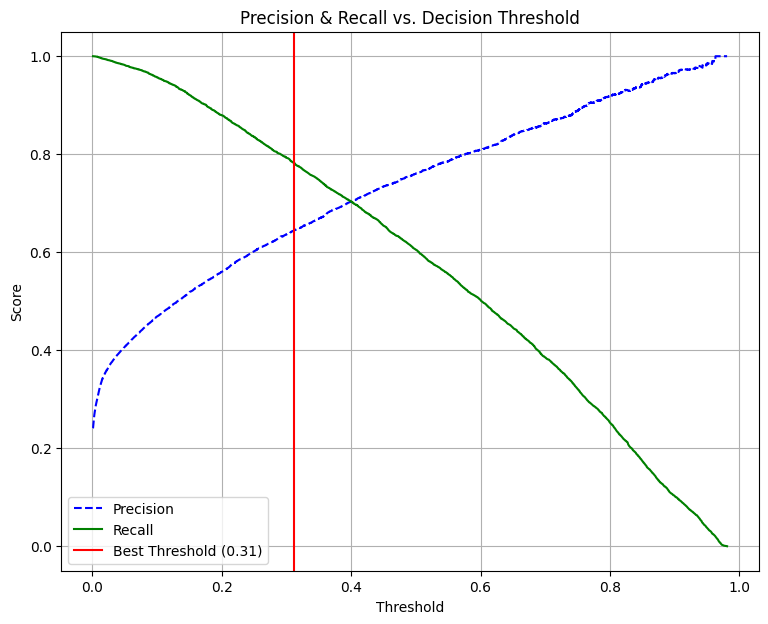

In [113]:
best_threshold_RBF_NN_original_NTT, y_proba_RBF_NN_original_NTT = best_threshold_NN(x_train_original_norm, y_train_original, model_RBFNN_Original_NTT)

509/509 [==============================] - 1s 1ms/step


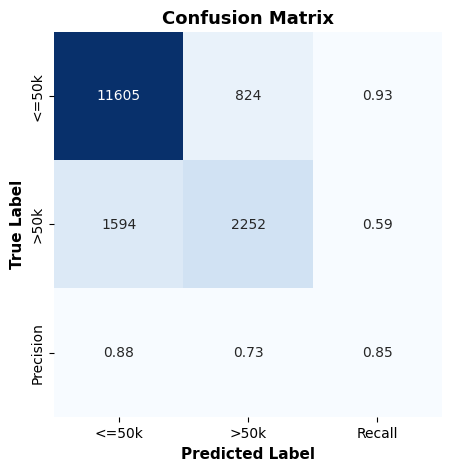

In [114]:
f1_RBF_NN_original_NTT, precision_RBF_NN_original_NTT, recall_RBF_NN_original_NTT, accuracy_RBF_NN_original_NTT = display_CM_NN(x_test_norm, y_test, 
                                                                                             0.5, model_RBFNN_Original_NTT)

In [115]:
Score_Information.append({'Model Name': 'RBF NN', 'DataSet Type': 'Original', 'Low Income Precision': precision_RBF_NN_original_NTT[0], 
                          'High Income Precision': precision_RBF_NN_original_NTT[1], 'Low Income Recall': recall_RBF_NN_original_NTT[0], 
                          'High Income Recall': recall_RBF_NN_original_NTT[1], 'Accuracy': accuracy_RBF_NN_original_NTT, 
                          'Mean F1 Score': f1_RBF_NN_original_NTT, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

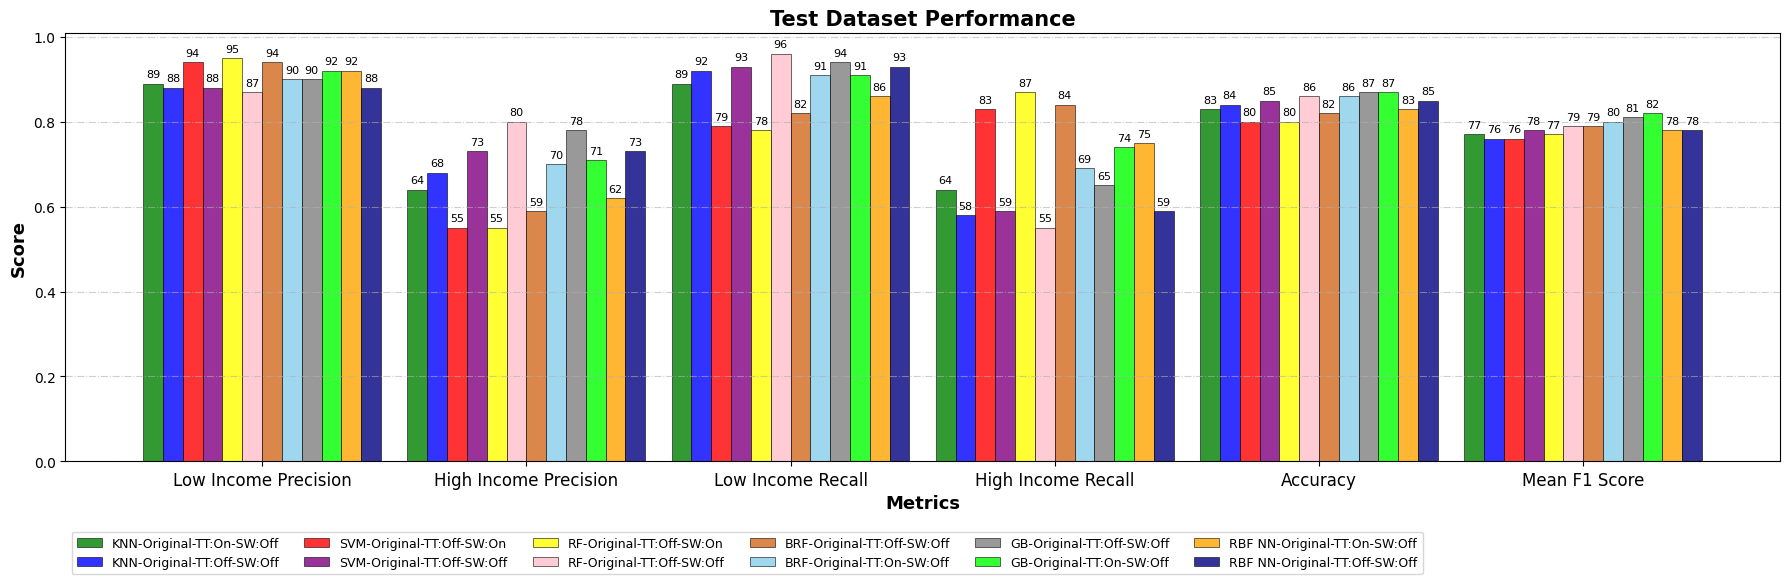

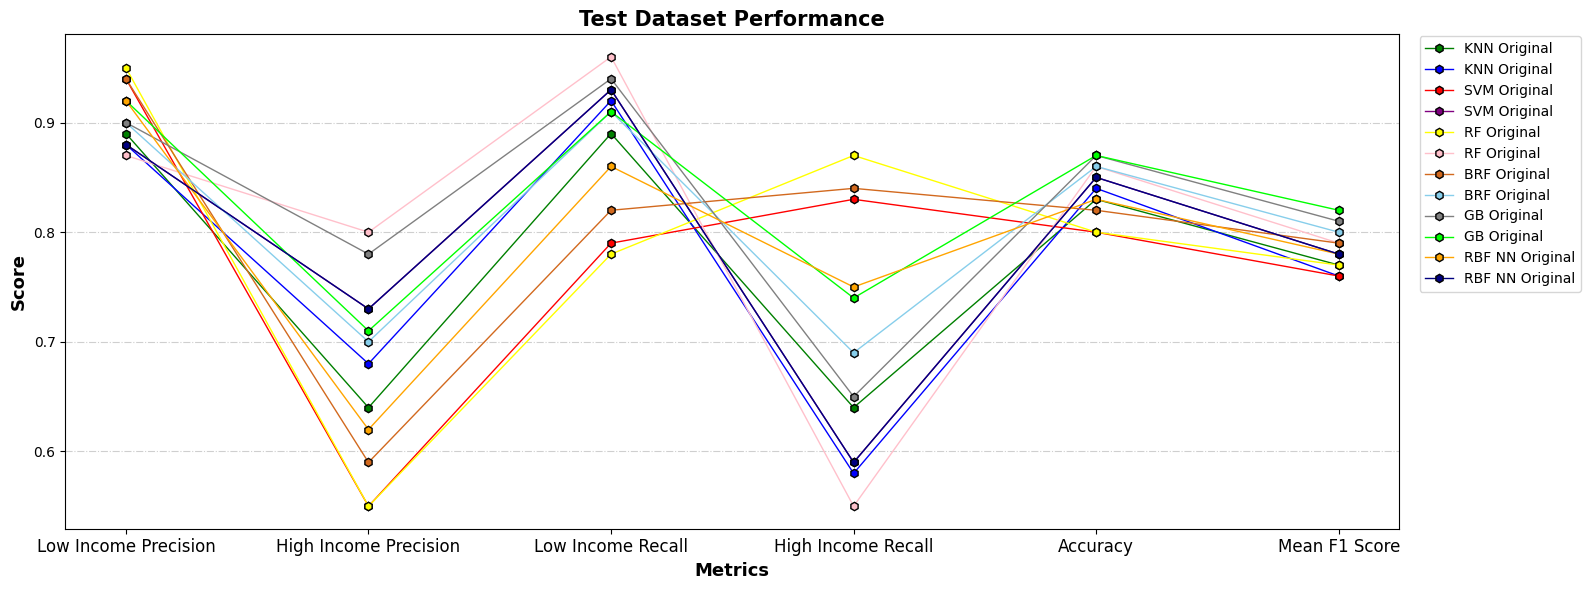

In [116]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'chocolate', 'skyblue', 'gray', 'lime', 'orange', 'navy']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(18, 6))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val*100:.0f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)

ncol = 6 # Number of labels per line
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left', 
           ncol=ncol, fontsize=9, frameon=True)    # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## XGBoost

In [43]:
XGB_model = XGBClassifier(random_state=42, n_jobs=-1)

XGB_N_Estimators = np.arange(start=50, stop=501, step=25)
XGB_learning_rate = [0.1, 0.2, 0.3]
XGB_max_depth = [3, 5, 7]
XGB_gamma = [0, 0.3, 2]  # gamma
XGBmin_child_weight = [0, 1, 2, 4]  
XGB_reg_lambda = [0.1, 1, 5, 10]
XGB_subsample = [0.6, 0.8, 1.0]

param_grid_XGB = {
    'n_estimators': XGB_N_Estimators,
    'learning_rate': XGB_learning_rate,
    'max_depth': XGB_max_depth,
    'reg_lambda': XGB_reg_lambda,
    'gamma': XGB_gamma,
    # 'subsample': XGB_subsample,
    # 'min_child_weight': XGBmin_child_weight,
}

#### Original Data - Non Tune Threshold

In [44]:
XGB_model_optimized_GS_Original_NTT = HalvingGridSearchCV(estimator=XGB_model, param_grid=param_grid_XGB, scoring='f1_macro', cv=StKFold, return_train_score=True, 
                                                          factor=3, resource='n_samples', max_resources='auto', random_state=42, verbose=3, n_jobs=5)
XGB_model_optimized_GS_Original_NTT.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 44
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2052
n_resources: 44
Fitting 5 folds for each of 2052 candidates, totalling 10260 fits
----------
iter: 1
n_candidates: 684
n_resources: 132
Fitting 5 folds for each of 684 candidates, totalling 3420 fits
----------
iter: 2
n_candidates: 228
n_resources: 396
Fitting 5 folds for each of 228 candidates, totalling 1140 fits
----------
iter: 3
n_candidates: 76
n_resources: 1188
Fitting 5 folds for each of 76 candidates, totalling 380 fits
----------
iter: 4
n_candidates: 26
n_resources: 3564
Fitting 5 folds for each of 26 candidates, totalling 130 fits
----------
iter: 5
n_candidates: 9
n_resources: 10692
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 6
n_candidates: 3
n_resources: 32076
Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'gamma': [0, 0.3, ...], 'learning_rate': [0.1, 0.2, ...], 'max_depth': [3, 5, ...], 'n_estimators': array([ 50, ...50, 475, 500]), ...}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [ ]:
best_score_XGB_original_NTT = XGB_model_optimized_GS_Original_NTT.best_score_
print(f'XGB Best Score: {best_score_XGB_original_NTT:.2f}')
best_params_XGB_original_NTT = XGB_model_optimized_GS_Original_NTT.best_params_
print(f'XGB Best Score: {best_params_XGB_original_NTT}')

Best_XGB_original_NTT_Estimator = XGB_model_optimized_GS_Original_NTT.best_estimator_

GB Best Score: 0.82
GB Best Score: {'gamma': 0.3, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 450, 'reg_lambda': 1}


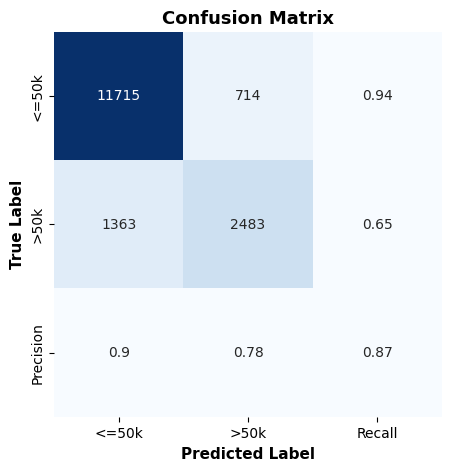

In [47]:
f1_XGB_original_NTT, precision_XGB_original_NTT, recall_XGB_original_NTT, accuracy_XGB_original_NTT = display_CM(x_test, y_test, 
                                                                                             0.5, Best_XGB_original_NTT_Estimator,0)

In [117]:
Score_Information.append({'Model Name': 'XGB', 'DataSet Type': 'Original', 'Low Income Precision': precision_XGB_original_NTT[0], 
                          'High Income Precision': precision_XGB_original_NTT[1], 'Low Income Recall': recall_XGB_original_NTT[0], 
                          'High Income Recall': recall_XGB_original_NTT[1], 'Accuracy': accuracy_XGB_original_NTT, 
                          'Mean F1 Score': f1_XGB_original_NTT, 'Tune Threshold': 'Off', 'Sample Weight': 'Off'})

#### Original Data - Tune Threshold

In [ ]:
best_score_XGB_original_TT = XGB_model_optimized_GS_Original_NTT.best_score_
print(f'XGB Best Score: {best_score_XGB_original_TT:.2f}')
best_params_XGB_original_TT = XGB_model_optimized_GS_Original_NTT.best_params_
print(f'XGB Best Score: {best_params_XGB_original_TT}')

Best_XGB_original_TT_Estimator = XGB_model_optimized_GS_Original_NTT.best_estimator_

GB Best Score: 0.82
GB Best Score: {'gamma': 0.3, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 450, 'reg_lambda': 1}


Best Threshold : 0.41
Best F1 Score for high income : 0.76


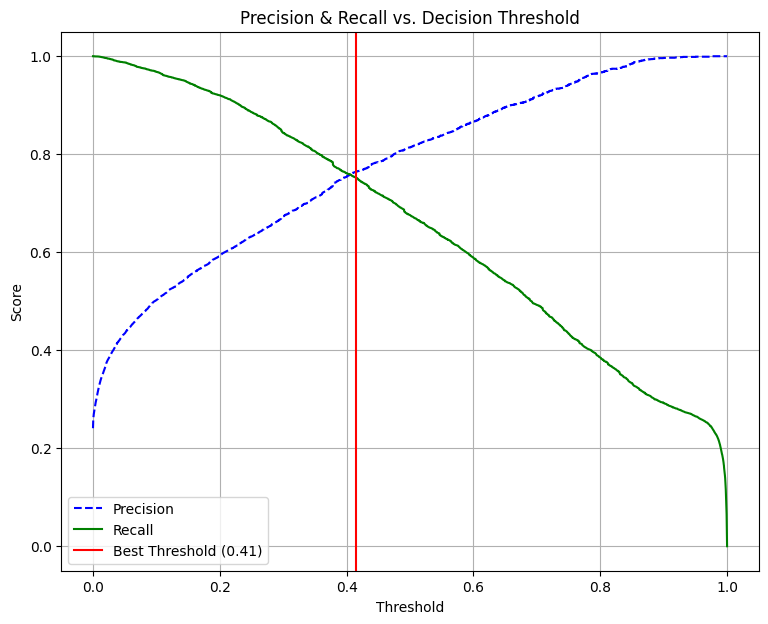

In [119]:
best_threshold_XGB_original_TT, y_proba_XGB_original_TT = best_threshold(x_train_original, y_train_original, 
                                                                       Best_XGB_original_TT_Estimator)

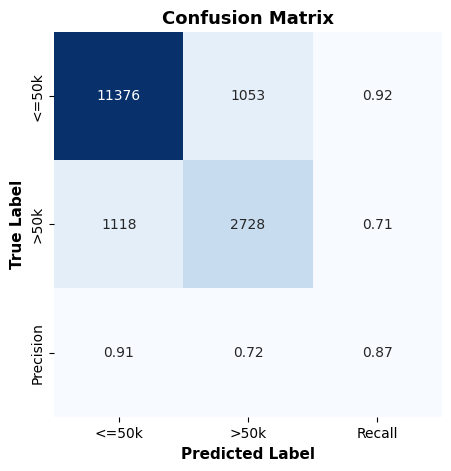

In [120]:
f1_XGB_original_TT, precision_XGB_original_TT, recall_XGB_original_TT, accuracy_XGB_original_TT = display_CM(x_test, y_test, 
                                                                                             best_threshold_XGB_original_TT, 
                                                                                             Best_XGB_original_TT_Estimator, 1)

In [121]:
Score_Information.append({'Model Name': 'XGB', 'DataSet Type': 'Original', 'Low Income Precision': precision_XGB_original_TT[0], 
                          'High Income Precision': precision_XGB_original_TT[1], 'Low Income Recall': recall_XGB_original_TT[0], 
                          'High Income Recall': recall_XGB_original_TT[1], 'Accuracy': accuracy_XGB_original_TT, 
                          'Mean F1 Score': f1_XGB_original_TT, 'Tune Threshold': 'On', 'Sample Weight': 'Off'})

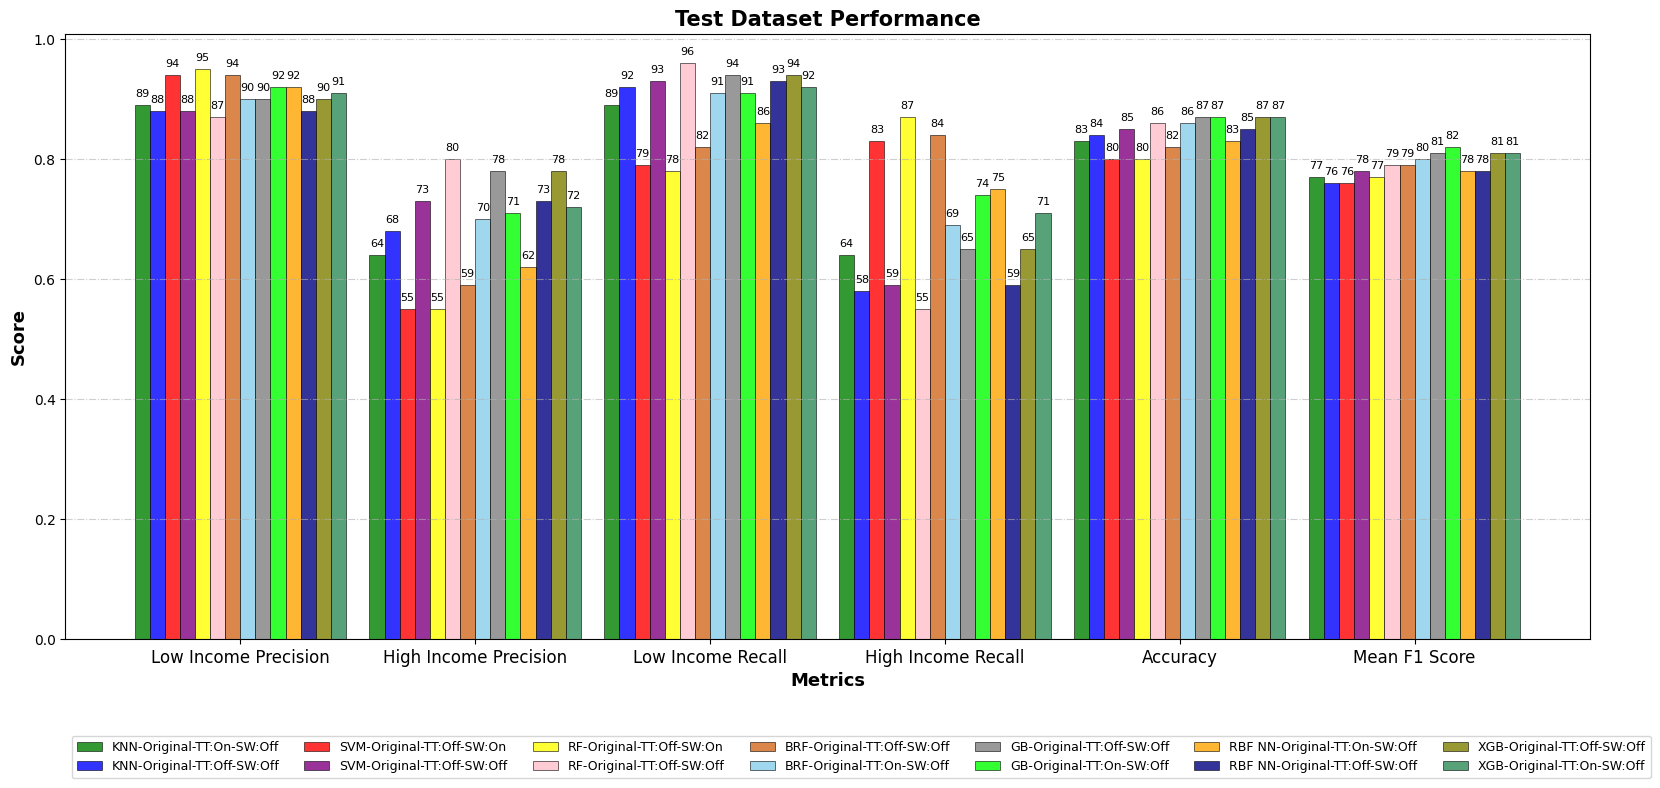

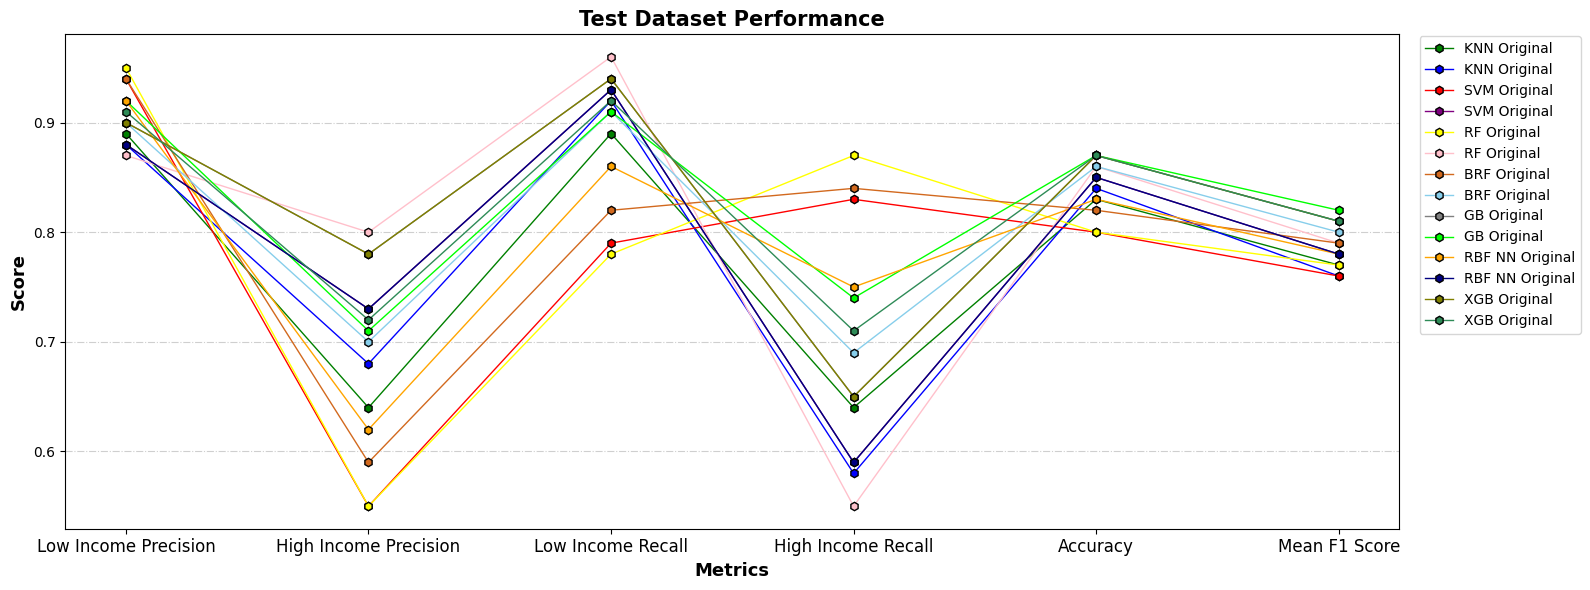

In [122]:
## Bar Chart

colors_chosen = ['green', 'blue', 'red', 'purple', 'yellow', 'pink', 'chocolate', 'skyblue', 'gray', 'lime', 'orange', 'navy',
                 'olive', 'seagreen']
DF_Score_Information = pd.DataFrame(Score_Information)

fig = plt.figure(figsize=(18, 8))

metrics = [col for col in DF_Score_Information.columns if col != 'Model Name' and col != 'DataSet Type' and col != 'Tune Threshold'
            and col != 'Sample Weight']

x = np.arange(len(metrics))    
width = 0.9 / DF_Score_Information.shape[0]             

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    Threshold_State = row['Tune Threshold']
    Sample_Weight_State = row['Sample Weight']

    values = [row[metric] for metric in metrics]
    
    # Calculate bar positions
    bar_positions = x + (j - len(DF_Score_Information)/2 + 0.5) * width
    
    bars = plt.bar(bar_positions, values, width, 
                   color=colors_chosen[j % len(colors_chosen)], 
                   label=f'{model_name}-{Data_Type}-TT:{Threshold_State}-SW:{Sample_Weight_State}', 
                   edgecolor='black', 
                   linewidth=0.5,
                   alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val*100:.0f}', ha='center', va='bottom', fontsize=8, rotation=0)

# Customize the plot
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)

ncol = 7 # Number of labels per line
plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left', 
           ncol=ncol, fontsize=9, frameon=True)    # write Upper Left to locate legend outside the plot based bbox_to_anchor values

plt.tight_layout()
plt.show()

##Plot

fig = plt.figure(figsize=(16,6))

for j, (idx, row) in enumerate(DF_Score_Information.iterrows()):
    model_name = row['Model Name']
    Data_Type = row['DataSet Type']
    values = [row[metric] for metric in metrics]

    plt.plot(x, values, color = colors_chosen[j] , marker = 'h', mec = 'k', label=f'{model_name} {Data_Type}', linewidth= 1)
    
plt.title('Test Dataset Performance', fontsize=15, weight='bold')
plt.xlabel('Metrics', fontsize=13, weight='bold')
plt.ylabel('Score', fontsize=13, weight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.grid(True, axis='y', linestyle='-.', alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
GBC_model_Final  = GradientBoostingClassifier(random_state=42) 

GBC_N_Estimators_Final = np.arange(start=20, stop=501, step=20)
GBC_learning_rate_Final = [0.05, 0.1, 0.2, 0.3, 0.4]
max_depth_GB_Final = [3, 5, 6]
min_samples_leaf_GB_Final = [1, 5, 10 ,20]

param_grid_GB_Final  = {
    'n_estimators': GBC_N_Estimators_Final  ,
    'learning_rate' : GBC_learning_rate_Final  ,
    'max_depth' : max_depth_GB_Final  ,
    'min_samples_leaf' : min_samples_leaf_GB_Final ,
}

In [96]:
GBC_model_optimized_GS_Original_Final = HalvingGridSearchCV(estimator=GBC_model_Final, param_grid=param_grid_GB_Final, 
                                                            scoring='f1_macro', cv=StKFold, return_train_score=True, factor=3, 
                                                            resource='n_samples', max_resources='auto', random_state=42, 
                                                            verbose=3, n_jobs=-1) 

GBC_model_optimized_GS_Original_Final.fit(x_train_original, column_or_1d(y_train_original))

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 44
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1200
n_resources: 44
Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
----------
iter: 1
n_candidates: 400
n_resources: 132
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
----------
iter: 2
n_candidates: 134
n_resources: 396
Fitting 5 folds for each of 134 candidates, totalling 670 fits
----------
iter: 3
n_candidates: 45
n_resources: 1188
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 4
n_candidates: 15
n_resources: 3564
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 5
n_candidates: 5
n_resources: 10692
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 6
n_candidates: 2
n_resources: 32076
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': array([ 20, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [98]:
best_score_GB_Original_Final = GBC_model_optimized_GS_Original_Final.best_score_
print(f'GB Best Score: {best_score_GB_Original_Final:.2f}')
best_params_GB_Original_Final = GBC_model_optimized_GS_Original_Final.best_params_
print(f'GB Best Score: {best_params_GB_Original_Final}')

Best_GB_Original_Final_Estimator = GBC_model_optimized_GS_Original_Final.best_estimator_

GB Best Score: 0.82
GB Best Score: {'learning_rate': 0.05, 'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 180}


Best Threshold : 0.38
Best F1 Score for high income : 0.76


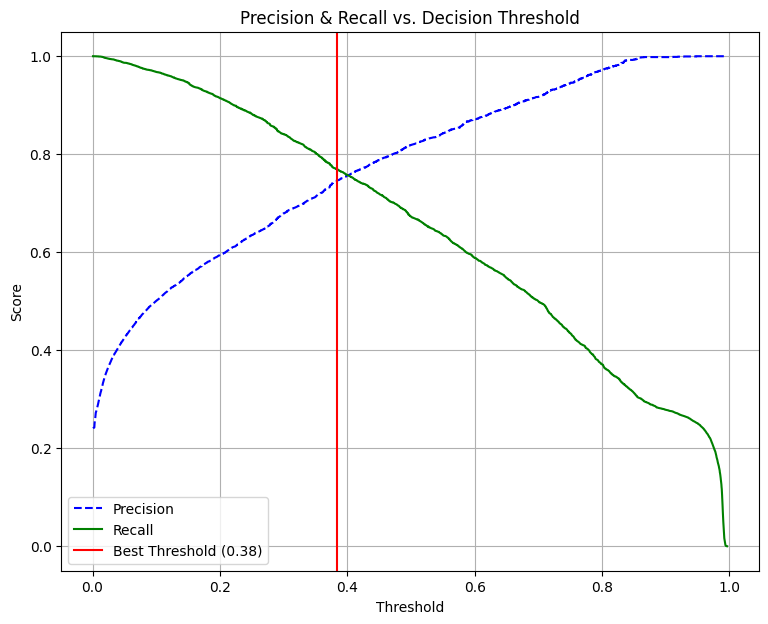

In [99]:
best_threshold_GB_Original_Final, y_proba_GB_Original_Final = best_threshold(x_train_original, y_train_original, 
                                                                       Best_GB_Original_Final_Estimator)

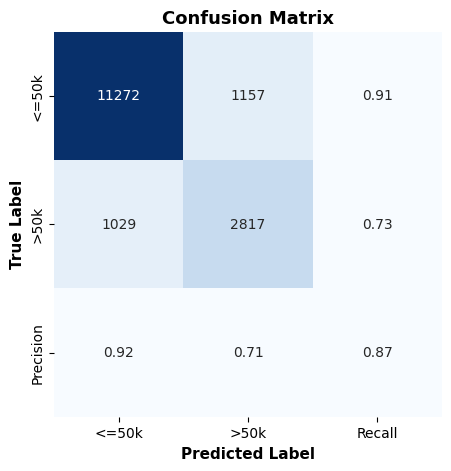

F1 Score : 0.82


In [100]:
f1_GB_Original_Final, precision_GB_Original_Final, recall_GB_Original_Final, accuracy_GB_Original_Final = display_CM(x_test, y_test, 
                                                                                             best_threshold_GB_Original_Final, 
                                                                                             Best_GB_Original_Final_Estimator, 1)
print(f'F1 Score : {f1_GB_Original_Final}')

In [111]:
GBC_model_optimized_GS_Original_Final_RFE = HalvingGridSearchCV(estimator=GBC_model_Final, param_grid=param_grid_GB_Final, 
                                                            scoring='f1_macro', cv=StKFold, return_train_score=True, factor=3, 
                                                            resource='n_samples', max_resources='auto', random_state=42, 
                                                            verbose=3, n_jobs=-1) 

GBC_model_optimized_GS_Original_Final_RFE.fit(x_train_original_RFE, column_or_1d(y_train_original))

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 44
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1200
n_resources: 44
Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
----------
iter: 1
n_candidates: 400
n_resources: 132
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
----------
iter: 2
n_candidates: 134
n_resources: 396
Fitting 5 folds for each of 134 candidates, totalling 670 fits
----------
iter: 3
n_candidates: 45
n_resources: 1188
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 4
n_candidates: 15
n_resources: 3564
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 5
n_candidates: 5
n_resources: 10692
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 6
n_candidates: 2
n_resources: 32076
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': array([ 20, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [112]:
best_score_GB_Original_RFE = GBC_model_optimized_GS_Original_Final_RFE.best_score_
print(f'GB Best Score: {best_score_GB_Original_RFE:.3f}')
best_params_GB_Original_RFE = GBC_model_optimized_GS_Original_Final_RFE.best_params_
print(f'GB Best Score: {best_params_GB_Original_RFE}')

Best_GB_Original_RFE_Estimator = GBC_model_optimized_GS_Original_Final_RFE.best_estimator_

GB Best Score: 0.784
GB Best Score: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 260}


Best Threshold : 0.37
Best F1 Score for high income : 0.70


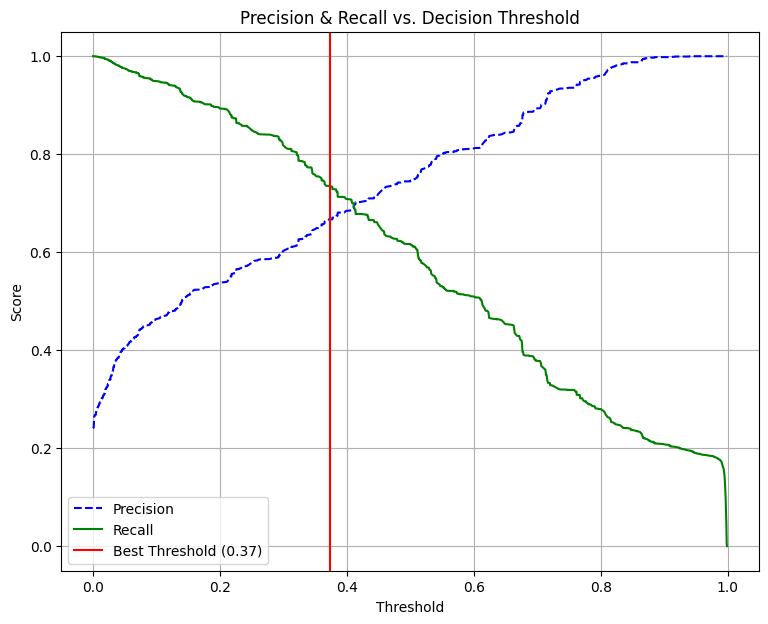

In [113]:
best_threshold_GB_Original_RFE, y_proba_GB_Original_RFE = best_threshold(x_train_original_RFE, y_train_original, 
                                                                       Best_GB_Original_RFE_Estimator)

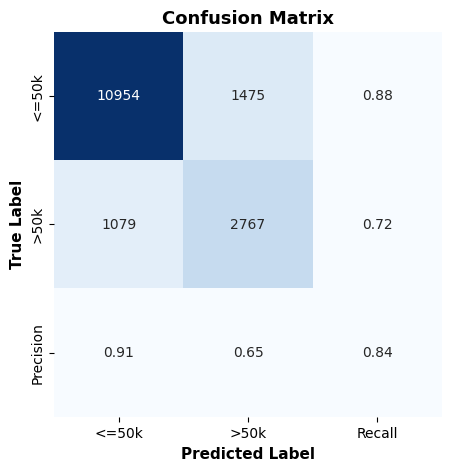

F1 Score : 0.79


In [114]:
f1_GB_Original_RFE, precision_GB_Original_RFE, recall_GB_Original_RFE, accuracy_GB_Original_RFE = display_CM(x_test_RFE, y_test, 
                                                                                             best_threshold_GB_Original_RFE, 
                                                                                             Best_GB_Original_RFE_Estimator, 1)
print(f'F1 Score : {f1_GB_Original_RFE}')

In [107]:
GBC_model_optimized_GS_Original_Final_MI = HalvingGridSearchCV(estimator=GBC_model_Final, param_grid=param_grid_GB_Final, 
                                                            scoring='f1_macro', cv=StKFold, return_train_score=True, factor=3, 
                                                            resource='n_samples', max_resources='auto', random_state=42, 
                                                            verbose=3, n_jobs=-1) 

GBC_model_optimized_GS_Original_Final_MI.fit(x_train_original_MI, column_or_1d(y_train_original))

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 44
max_resources_: 32533
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1200
n_resources: 44
Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
----------
iter: 1
n_candidates: 400
n_resources: 132
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
----------
iter: 2
n_candidates: 134
n_resources: 396
Fitting 5 folds for each of 134 candidates, totalling 670 fits
----------
iter: 3
n_candidates: 45
n_resources: 1188
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 4
n_candidates: 15
n_resources: 3564
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 5
n_candidates: 5
n_resources: 10692
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 6
n_candidates: 2
n_resources: 32076
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': array([ 20, ...60, 480, 500])}"
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,'exhaust'
,aggressive_elimination,False
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1_macro'
,refit,True
,error_score,nan


In [108]:
best_score_GB_Original_MI = GBC_model_optimized_GS_Original_Final_MI.best_score_
print(f'GB Best Score: {best_score_GB_Original_MI:.3f}')
best_params_GB_Original_MI = GBC_model_optimized_GS_Original_Final_MI.best_params_
print(f'GB Best Score: {best_params_GB_Original_MI}')

Best_GB_Original_MI_Estimator = GBC_model_optimized_GS_Original_Final_MI.best_estimator_

GB Best Score: 0.787
GB Best Score: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}


Best Threshold : 0.34
Best F1 Score for high income : 0.70


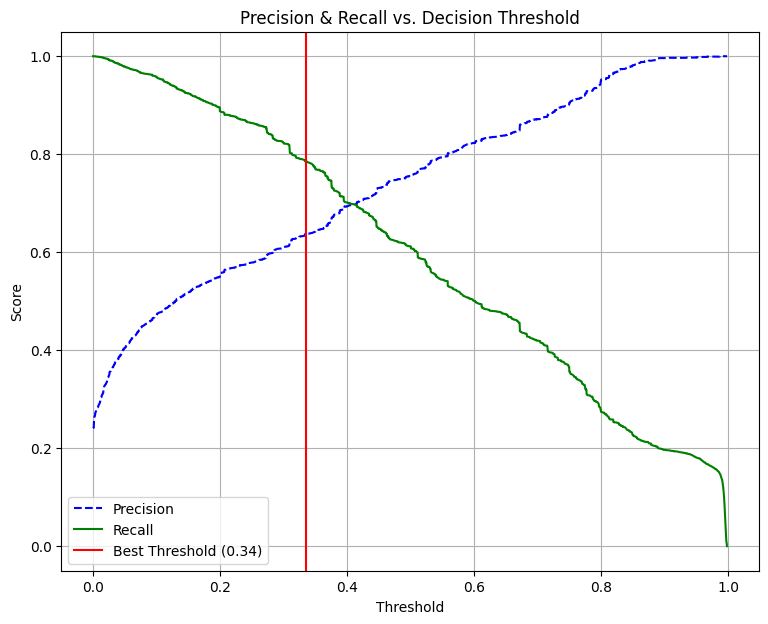

In [109]:
best_threshold_GB_Original_MI, y_proba_GB_Original_MI = best_threshold(x_train_original_MI, y_train_original, 
                                                                       Best_GB_Original_MI_Estimator)

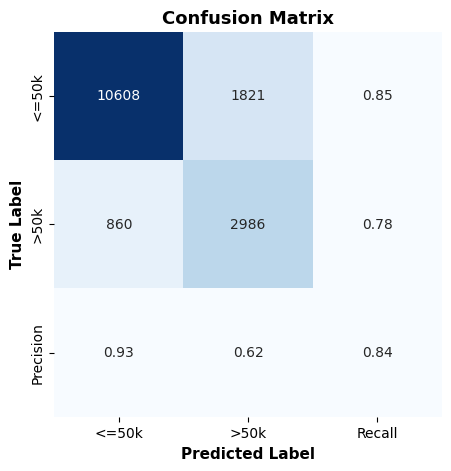

F1 Score : 0.79


In [110]:
f1_GB_Original_MI, precision_GB_Original_MI, recall_GB_Original_MI, accuracy_GB_Original_MI = display_CM(x_test_MI, y_test, 
                                                                                             best_threshold_GB_Original_MI, 
                                                                                             Best_GB_Original_MI_Estimator, 1)
print(f'F1 Score : {f1_GB_Original_MI}')

In [162]:
# END